# Where is EAT Dice actually lost, and does 2.5D context fix it?

**Scratch / diagnostic notebook — untracked, safe to delete.**

Volume Dice decomposes *exactly* into a per-slice weighted mean — no assumptions:

$$\mathrm{Dice}_{\text{vol}} \;=\; \sum_i w_i\,d_i,\qquad
w_i=\frac{p_i+g_i}{\sum_j (p_j+g_j)},\qquad
d_i=\frac{2\,|P_i\cap G_i|}{p_i+g_i}$$

and since $2|P_i \cap G_i| = p_i + g_i - \mathrm{FP}_i - \mathrm{FN}_i$, the *shortfall*
decomposes just as exactly:

$$1-\mathrm{Dice}_{\text{vol}} \;=\; \sum_i w_i(1-d_i) \;=\; \sum_i \frac{\mathrm{FP}_i+\mathrm{FN}_i}{\sum_j (p_j+g_j)}$$

So every slice gets an attributable, additive share of the Dice deficit, split into a
false-positive and a false-negative half. Everything below is that identity, checked
against the numbers already recorded in each run's `val_metrics_per_patient.csv`.

## ⚠️ Corrected 2026-09-06 — the original comparison was confounded

This notebook originally compared `both_baseline_dice_ce` against `both_ctx_cs3` and read
the difference as the effect of 2.5D context. Those two runs differ in **two** things:
`context_slices` (0 → 3) *and* `augment` (`False` → `True`). The config check below
asserted on eight keys but not on `augment`, so the confound passed silently.

The config-matched control for the context runs is **`both_data_aug_dice_ce`**
(`augment=True, context_slices=0`). Against it, context does essentially nothing to EAT —
see §0 below. All three arms are now carried through, so the two factors are separated
instead of pooled:

| arm | run | `augment` | `context_slices` |
|---|---|---|---|
| `baseline` | `both_baseline_dice_ce` | `False` | 0 |
| `aug` (**control**) | `both_data_aug_dice_ce` | `True` | 0 |
| `cs3` (**treatment**) | `both_ctx_cs3` | `True` | 3 |

`aug` → `cs3` is the one clean single-factor contrast. `baseline` → `aug` is the
augmentation effect, carried so the previously-reported `baseline` → `cs3` gain can be
split into its two parts rather than credited entirely to context.

### Cases

All arms use `split_seed=0` and identical folds, so each patient sits in the same
validation fold in all three runs — a clean paired comparison. Held-out **test** patients
are in no fold and are never touched here.

The two cases are **the two lowest-EAT patients under the control arm**. That criterion is
deliberately independent of the contrast being tested: picking the patient where context
helped most would be selecting on the outcome, and against a null cohort effect that
selects noise.

| patient | baseline | aug | cs3 | aug → cs3 | HD95 aug | HD95 cs3 | why this case |
|---|---|---|---|---|---|---|---|
| `CADRE_1875` | 0.6765 | 0.6880 | 0.6795 | **−0.0085** | 9.46 mm | 10.20 mm | worst EAT in the cohort; context makes it slightly *worse* |
| `CADRE_1851` | 0.6408 | 0.7010 | 0.7379 | **+0.0369** | 6.37 mm | 4.00 mm | 2nd worst; the largest context gain in the cohort |

Between them they bracket the entire range of the context effect (−0.029 … +0.037), whose
cohort mean is −0.0004. Of `CADRE_1851`'s +0.097 `baseline` → `cs3` gain — originally
attributed to context in full — **+0.060 is augmentation and +0.037 is context**.

In [1]:
import json, csv, sys, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import binary_dilation, generate_binary_structure
from scipy.stats import wilcoxon

REPO = Path.cwd()
assert (REPO / 'train.py').exists(), f'run this notebook from the repo root, not {REPO}'
sys.path.insert(0, str(REPO))

from unet import UNet
from utils.data_loading import VolumeMRIDataset
from utils import metrics
from train import n_channels_for, BOTH_CLASS_NAMES, dir_img, dir_mask

EAT_CLS   = 5
CLASS_LBL = {0: 'background', **BOTH_CLASS_NAMES}          # 0..5

# Each arm declares the config it is SUPPOSED to have, and the next-but-one cell asserts
# the run on disk actually matches. Declaring the factors is what keeps a second variable
# from riding along unnoticed: the first version of this notebook compared `baseline` with
# `cs3` and credited the difference to context, but those runs also differ in `augment`.
ARMS = {
    'baseline': dict(run='both_baseline_dice_ce', augment=False, context_slices=0),
    'aug':      dict(run='both_data_aug_dice_ce', augment=True,  context_slices=0),
    'cs3':      dict(run='both_ctx_cs3',          augment=True,  context_slices=3),
}
FACTORS = ('augment', 'context_slices')     # everything else must match across arms
CONTROL, TREATMENT = 'aug', 'cs3'           # the one clean single-factor contrast

PATIENTS = ['CADRE_1851', 'CADRE_1875']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '| classes:', CLASS_LBL)

/hpc/jgeo610/Virtual_ENV/unet_env/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cuda | classes: {0: 'background', 1: 'LV', 2: 'RV', 3: 'LA', 4: 'RA', 5: 'EAT'}


In [2]:
# --- plot style -------------------------------------------------------------
# Categorical slots from the validated reference palette (light mode).
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
C_MAGENTA, C_GREEN, C_VIOLET, C_RED = '#e87ba4', '#008300', '#4a3aa7', '#e34948'
SURFACE, INK, INK_2, INK_MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#8a8880'

# colour follows the arm, never its rank
ARM_COLOR = {'baseline': C_BLUE, 'aug': C_GREEN, 'cs3': C_ORANGE}
FN_COLOR, FP_COLOR = C_BLUE, C_ORANGE               # under- vs over-segmentation

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': INK_MUTED, 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelcolor': INK_2, 'axes.titlecolor': INK, 'axes.titlesize': 11,
    'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'axes.titlepad': 20,
    'text.color': INK, 'xtick.color': INK_2, 'ytick.color': INK_2,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'axes.labelsize': 9.5,
    'grid.color': '#e6e5e1', 'grid.linewidth': 0.7, 'axes.grid': True, 'axes.axisbelow': True,
    'legend.frameon': False, 'legend.fontsize': 9, 'font.size': 10,
    'lines.linewidth': 2.0, 'figure.dpi': 110,
})

def subtitle(ax, text):
    ax.text(0.0, 1.004, text, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=8.5, color=INK_2)

In [3]:
# --- locate, for each patient, the fold in which it was a VALIDATION case ----
def fold_configs(run_prefix):
    out = {}
    for p in sorted(glob.glob(f'checkpoints/{run_prefix}_kfold*/run_config.json')):
        cfg = json.load(open(p))
        cfg['_dir'] = Path(p).parent
        out[cfg['fold']] = cfg
    return out

CFGS = {arm: fold_configs(spec['run']) for arm, spec in ARMS.items()}
for arm, cfgs in CFGS.items():
    assert cfgs, f'{arm}: no run_config.json under checkpoints/{ARMS[arm]["run"]}_kfold*'

FOLD_OF = {}
for pid in PATIENTS:
    folds = {arm: [f for f, c in cfgs.items() if pid in c['val_patients']]
             for arm, cfgs in CFGS.items()}
    assert all(len(v) == 1 for v in folds.values()), f'{pid}: not a val patient exactly once: {folds}'
    assert len({v[0] for v in folds.values()}) == 1, f'{pid}: arms disagree on fold: {folds}'
    FOLD_OF[pid] = folds[CONTROL][0]

# Every arm must be the same experiment apart from the factors it declares. Asserting the
# DECLARED factors -- rather than just "these particular keys happen to match" -- is what
# makes a hidden second difference impossible: each arm must really have the factor values
# it claims, and every other key must be equal across all arms. The original version of
# this cell listed eight keys to compare and `augment` was not one of them.
SHARED = ('split_seed', 'phase', 'img_scale', 'n_classes', 'loss', 'k_folds', 'epochs',
          'batch_size', 'seed', 'arch', 'lr', 'lr_schedule', 'select_on',
          'val_patients', 'test_patients')

for pid, fold in FOLD_OF.items():
    ref = CFGS[CONTROL][fold]
    for arm, spec in ARMS.items():
        c = CFGS[arm][fold]
        for k in FACTORS:
            assert c[k] == spec[k], f'{arm} fold {fold}: declared {k}={spec[k]}, run has {c[k]}'
        for k in SHARED:
            assert c.get(k) == ref.get(k), \
                f'fold {fold}: {arm} differs from {CONTROL} on {k} ({c.get(k)} vs {ref.get(k)})'
        assert pid not in c['test_patients'], f'{pid} is a TEST patient — do not score it here'

# ...and the headline contrast must vary exactly one factor
differing = [k for k in FACTORS if ARMS[CONTROL][k] != ARMS[TREATMENT][k]]
assert differing == ['context_slices'], f'{CONTROL} vs {TREATMENT} differ on {differing}'

for pid, fold in FOLD_OF.items():
    print(f'{pid}: fold {fold}')
    for arm in ARMS:
        c = CFGS[arm][fold]
        print(f'    {arm:<9} {c["_dir"].name:<28} '
              f'augment={c["augment"]!s:<5} context_slices={c["context_slices"]}')
print(f'\nheadline contrast: {CONTROL} -> {TREATMENT}, differing only in {differing[0]}')

CADRE_1851: fold 4
    baseline  both_baseline_dice_ce_kfold4 augment=False context_slices=0
    aug       both_data_aug_dice_ce_kfold4 augment=True  context_slices=0
    cs3       both_ctx_cs3_kfold4          augment=True  context_slices=3
CADRE_1875: fold 0
    baseline  both_baseline_dice_ce_kfold0 augment=False context_slices=0
    aug       both_data_aug_dice_ce_kfold0 augment=True  context_slices=0
    cs3       both_ctx_cs3_kfold0          augment=True  context_slices=3

headline contrast: aug -> cs3, differing only in context_slices


In [4]:
# --- model + dataset loading (both cached; the two datasets share the disk cache) ---
_datasets, _models = {}, {}

def get_dataset(cfg):
    key = (cfg['context_slices'], cfg['img_scale'])
    if key not in _datasets:
        _datasets[key] = VolumeMRIDataset(dir_img, dir_mask, scale=cfg['img_scale'],
                                          phase=cfg['phase'], context_slices=cfg['context_slices'])
    return _datasets[key]

def get_model(cfg):
    key = str(cfg['_dir'])
    if key not in _models:
        net = UNet(n_channels=n_channels_for(cfg['phase'], cfg['context_slices']),
                   n_classes=cfg['n_classes'], bilinear=cfg['bilinear'])
        sd = torch.load(cfg['_dir'] / 'best.pth', map_location='cpu')
        sd.pop('mask_values', None)          # train.py injects this; load_state_dict would choke
        net.load_state_dict(sd)
        _models[key] = net.to(device).eval()
    return _models[key]

def patient_indices(dataset, pid):
    return [i for i, (p, _) in enumerate(dataset.index) if p == pid]

In [5]:
# --- the decomposition ------------------------------------------------------
def decompose(pred_vol, gt_vol, cls=EAT_CLS):
    # exact additive attribution of volume Dice (and its deficit) to slices
    g = (gt_vol == cls)
    p = (pred_vol == cls)
    flat = lambda v: v.reshape(v.shape[0], -1).sum(1).astype(np.float64)

    g_i, p_i = flat(g), flat(p)
    inter_i  = flat(g & p)
    fp_i     = flat(p & ~g)
    fn_i     = flat(g & ~p)

    D = (p_i + g_i).sum()
    with np.errstate(invalid='ignore', divide='ignore'):
        d_i = np.where(p_i + g_i > 0, 2 * inter_i / (p_i + g_i), np.nan)

    out = dict(gt=g_i, pred=p_i, inter=inter_i, fp=fp_i, fn=fn_i,
               w=(p_i + g_i) / D,
               dice_slice=d_i,
               deficit_fp=fp_i / D, deficit_fn=fn_i / D,
               deficit=(fp_i + fn_i) / D,
               dice_vol=2 * inter_i.sum() / D)

    # the identity is the whole point -- verify it rather than assume it
    assert np.isclose(np.nansum(out['w'] * np.nan_to_num(d_i)), out['dice_vol'])
    assert np.isclose(out['deficit'].sum(), 1 - out['dice_vol'])
    return out


def error_attribution(pred_vol, gt_vol, cls=EAT_CLS):
    # what EAT false positives really are, and what its false negatives became
    g, p = gt_vol == cls, pred_vol == cls
    fp, fn = p & ~g, g & ~p
    n = int(gt_vol.max()) + 1
    return {
        'fp_true_label':  np.bincount(gt_vol[fp].ravel(),   minlength=n).astype(float),
        'fn_pred_label':  np.bincount(pred_vol[fn].ravel(), minlength=n).astype(float),
    }


def rim_vs_detached(pred_vol, gt_vol, cls=EAT_CLS):
    # Split error voxels into boundary jitter around correct EAT vs errors away from it.
    #
    # EAT is thin and diffuse, so it has a very large perimeter-to-volume ratio: a
    # substantial share of its deficit is one-voxel rim disagreement that no
    # architecture change recovers. Errors NOT touching a correct EAT voxel are the
    # genuinely fixable part -- missed regions and hallucinations.
    g, p = gt_vol == cls, pred_vol == cls
    tp = g & p
    near = binary_dilation(tp, structure=generate_binary_structure(3, 1), iterations=1)
    err = (p & ~g) | (g & ~p)
    n_err = int(err.sum())
    return {'rim': int((err & near).sum()), 'detached': int((err & ~near).sum()), 'total': n_err}

In [6]:
# --- run both arms on both patients ----------------------------------------
R = {}   # (patient, arm) -> everything

for pid in PATIENTS:
    fold = FOLD_OF[pid]
    gt_ref = None
    for arm in ARMS:
        cfg = CFGS[arm][fold]
        ds  = get_dataset(cfg)
        net = get_model(cfg)
        idxs = patient_indices(ds, pid)
        pred_vol, gt_vol, ent = metrics.predict_volume(
            net, ds, idxs, device, amp=False, batch_size=8, return_entropy=True)

        if gt_ref is None:
            gt_ref = gt_vol
        else:
            assert np.array_equal(gt_ref, gt_vol), 'arms disagree on ground truth — not comparable'

        rec = decompose(pred_vol, gt_vol)
        rec.update(pred_vol=pred_vol, gt_vol=gt_vol, entropy=ent,
                   attribution=error_attribution(pred_vol, gt_vol),
                   rim=rim_vs_detached(pred_vol, gt_vol),
                   cfg=cfg, dataset=ds, indices=sorted(idxs, key=lambda i: ds.index[i][1]))
        R[(pid, arm)] = rec
        print(f'{pid:<14} {arm:<9} {pred_vol.shape[0]:>3} slices  volume Dice {rec["dice_vol"]:.4f}')

/tmp/ipykernel_20548/3767430556.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(cfg['_dir'] / 'best.pth', map_location='cpu')


CADRE_1851     baseline  100 slices  volume Dice 0.6408


CADRE_1851     aug       100 slices  volume Dice 0.7011


CADRE_1851     cs3       100 slices  volume Dice 0.7378


CADRE_1875     baseline   90 slices  volume Dice 0.6767


CADRE_1875     aug        90 slices  volume Dice 0.6880


CADRE_1875     cs3        90 slices  volume Dice 0.6795


In [7]:
# --- verify against the numbers already on disk -----------------------------
def recorded(arm, fold, pid, cls=EAT_CLS):
    path = CFGS[arm][fold]['_dir'] / 'val_metrics_per_patient.csv'
    for r in csv.DictReader(open(path)):
        if r['patient_id'] == pid and int(r['cls']) == cls:
            return float(r['dice'])
    raise KeyError((arm, pid))

print(f'{"patient":<14}{"arm":<10}{"recomputed":>12}{"in CSV":>10}{"diff":>10}')
for pid in PATIENTS:
    for arm in ARMS:
        got, exp = R[(pid, arm)]['dice_vol'], recorded(arm, FOLD_OF[pid], pid)
        print(f'{pid:<14}{arm:<10}{got:>12.4f}{exp:>10.4f}{got - exp:>10.2e}')
        assert abs(got - exp) < 2e-3, 'decomposition does not reproduce the recorded Dice'
print('\nDecomposition reproduces the recorded per-patient Dice — plots below are trustworthy.')

patient       arm         recomputed    in CSV      diff
CADRE_1851    baseline        0.6408    0.6408 -2.27e-05
CADRE_1851    aug             0.7011    0.7010  8.46e-05
CADRE_1851    cs3             0.7378    0.7379 -4.41e-05
CADRE_1875    baseline        0.6767    0.6765  1.51e-04
CADRE_1875    aug             0.6880    0.6880 -1.65e-05
CADRE_1875    cs3             0.6795    0.6795 -4.99e-05

Decomposition reproduces the recorded per-patient Dice — plots below are trustworthy.


## 0. Cohort context — separating augmentation from context

Two patients cannot tell you whether a change works. This is the population the cases are
drawn from, and it is the check that would have caught the original confound: the
apparent context effect is an augmentation effect.

In [8]:
# --- what the arms actually do to EAT, over every validation patient --------
def eat_dice(arm):
    d = {}
    for cfg in CFGS[arm].values():
        for r in csv.DictReader(open(cfg['_dir'] / 'val_metrics_per_patient.csv')):
            if int(r['cls']) == EAT_CLS:
                d[r['patient_id']] = float(r['dice'])
    return d

EAT_BY_ARM = {arm: eat_dice(arm) for arm in ARMS}
pids = sorted(set.intersection(*(set(d) for d in EAT_BY_ARM.values())))
assert not (set(pids) & set(CFGS[CONTROL][FOLD_OF[PATIENTS[0]]]['test_patients'])), \
    'a test patient leaked into the pooled validation set'

print(f'pooled validation EAT Dice, n={len(pids)} patients\n')
for arm in ARMS:
    print(f'  {arm:<9} {ARMS[arm]["run"]:<24} {np.mean([EAT_BY_ARM[arm][p] for p in pids]):.4f}')

print('\npaired contrasts (Wilcoxon signed-rank):')
for a, b, label in ((CONTROL,  TREATMENT, 'context      -- single factor'),
                    ('baseline', CONTROL,  'augmentation -- single factor'),
                    ('baseline', TREATMENT, 'both         -- CONFOUNDED, the original')):
    x = np.array([EAT_BY_ARM[a][p] for p in pids])
    y = np.array([EAT_BY_ARM[b][p] for p in pids])
    d = y - x
    print(f'  {a:>8} -> {b:<9} {label}   mean {d.mean():+.4f}  median {np.median(d):+.4f}  '
          f'improved {(d > 0).sum():>2}/{len(d)}  p={wilcoxon(y, x).pvalue:.4f}')

print('\nThe context contrast is null; the augmentation contrast is not. The confounded\n'
      'contrast is almost entirely the augmentation effect, which is why the two cases\n'
      'below are selected on control-arm difficulty, not on the context difference.')

pooled validation EAT Dice, n=42 patients

  baseline  both_baseline_dice_ce    0.7544
  aug       both_data_aug_dice_ce    0.7680
  cs3       both_ctx_cs3             0.7676

paired contrasts (Wilcoxon signed-rank):
       aug -> cs3       context      -- single factor   mean -0.0004  median -0.0015  improved 18/42  p=0.5439
  baseline -> aug       augmentation -- single factor   mean +0.0136  median +0.0095  improved 33/42  p=0.0001
  baseline -> cs3       both         -- CONFOUNDED, the original   mean +0.0132  median +0.0100  improved 28/42  p=0.0002

The context contrast is null; the augmentation contrast is not. The confounded
contrast is almost entirely the augmentation effect, which is why the two cases
below are selected on control-arm difficulty, not on the context difference.


## 1. Extent profile — where EAT is, and where the model puts it

Ground truth (grey) against each arm's prediction. Divergence at the ends of the
z-extent is an extent error; divergence in the middle is a magnitude error.

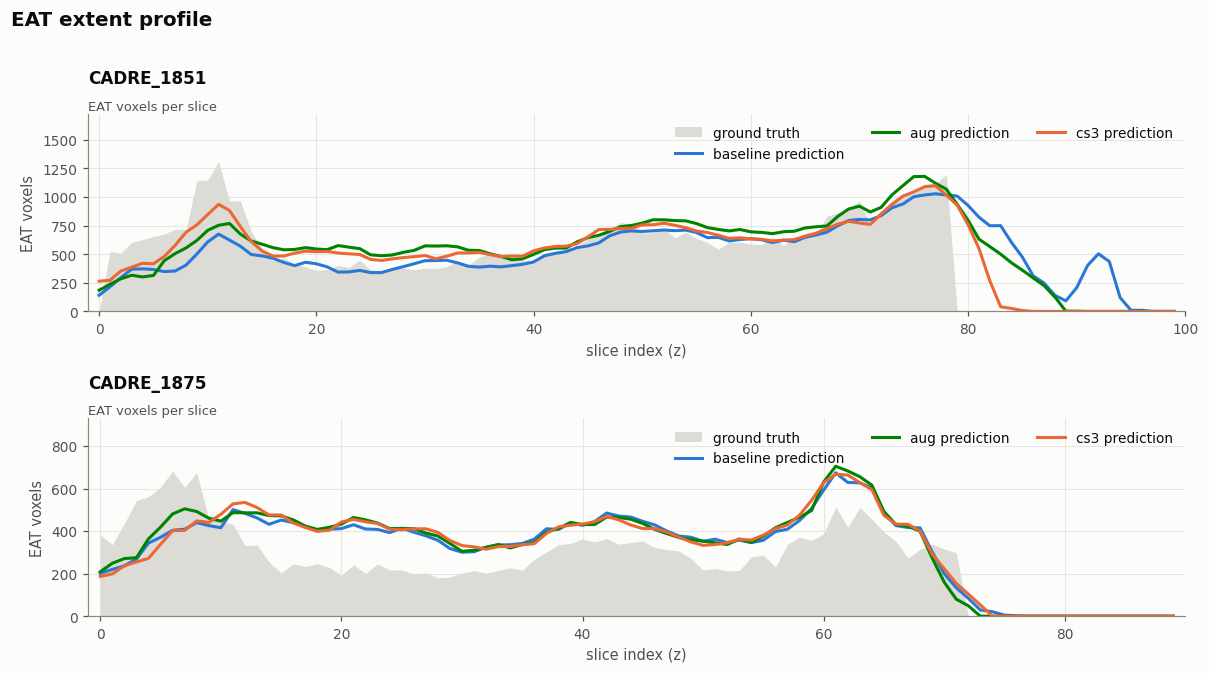

In [9]:
fig, axes = plt.subplots(len(PATIENTS), 1, figsize=(11, 3.1 * len(PATIENTS)), sharex=False)
axes = np.atleast_1d(axes)

for ax, pid in zip(axes, PATIENTS):
    z = np.arange(len(R[(pid, 'baseline')]['gt']))
    ax.fill_between(z, R[(pid, 'baseline')]['gt'], color='#dcdbd6', linewidth=0,
                    label='ground truth', zorder=1)
    for arm in ARMS:
        ax.plot(z, R[(pid, arm)]['pred'], color=ARM_COLOR[arm], linewidth=2.0,
                label=f'{arm} prediction', zorder=3)
    ax.set_ylim(0, max(R[(pid, 'baseline')]['gt'].max(),
                       *(R[(pid, a)]['pred'].max() for a in ARMS)) * 1.32)
    ax.set_xlim(-1, len(z))
    ax.set_title(pid)
    subtitle(ax, 'EAT voxels per slice')
    ax.set_xlabel('slice index (z)')
    ax.set_ylabel('EAT voxels')
    ax.legend(loc='upper right', ncol=3)

fig.suptitle('EAT extent profile', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 2. Per-slice Dice, sized by how much that slice weighs

The line is the slice's own Dice $d_i$; the marker area is its weight $w_i$. A low point
with a tiny marker is a bad slice that barely matters; a low point with a big marker is
where the score is actually lost.

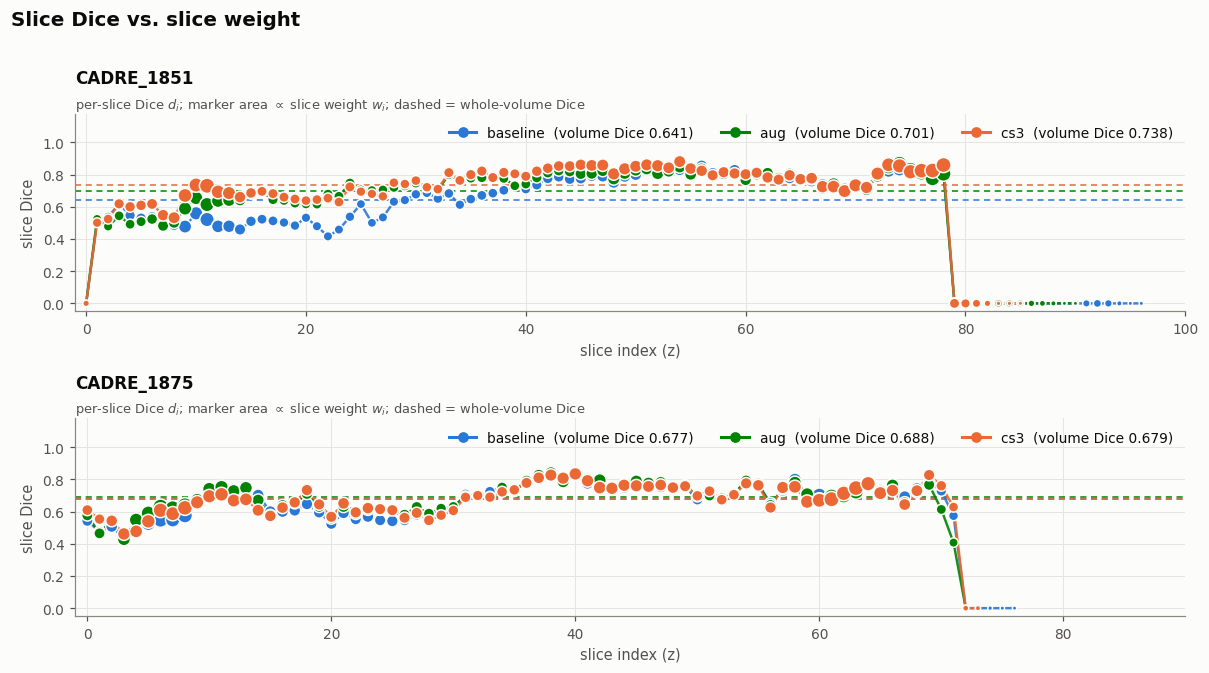

In [10]:
fig, axes = plt.subplots(len(PATIENTS), 1, figsize=(11, 3.1 * len(PATIENTS)))
axes = np.atleast_1d(axes)

for ax, pid in zip(axes, PATIENTS):
    for arm in ARMS:
        r = R[(pid, arm)]
        z = np.arange(len(r['dice_slice']))
        ax.plot(z, r['dice_slice'], color=ARM_COLOR[arm], linewidth=1.6, alpha=0.9, zorder=2)
        ax.scatter(z, r['dice_slice'], s=8 + 4200 * r['w'], color=ARM_COLOR[arm],
                   edgecolor=SURFACE, linewidth=1.0, zorder=3)
        ax.axhline(r['dice_vol'], color=ARM_COLOR[arm], linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
    ax.set_ylim(-0.05, 1.18)
    ax.set_xlim(-1, len(z))
    ax.set_title(pid)
    subtitle(ax, 'per-slice Dice $d_i$; marker area $\\propto$ slice weight $w_i$; dashed = whole-volume Dice')
    ax.set_xlabel('slice index (z)')
    ax.set_ylabel('slice Dice')
    ax.legend(handles=[Line2D([], [], color=ARM_COLOR[a], lw=2, marker='o', markersize=6,
                              label=f'{a}  (volume Dice {R[(pid, a)]["dice_vol"]:.3f})') for a in ARMS],
              loc='upper right', ncol=len(ARMS))

fig.suptitle('Slice Dice vs. slice weight', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 3. The headline — which slices carry the deficit, and is it FP or FN?

Bar heights are $w_i(1-d_i)$, split into its false-negative (under-segmentation) and
false-positive (over-segmentation) halves. **The bars sum exactly to $1-\mathrm{Dice}$**,
so the two panels are directly comparable in absolute terms: the area removed between
baseline and cs3 *is* the Dice gained.

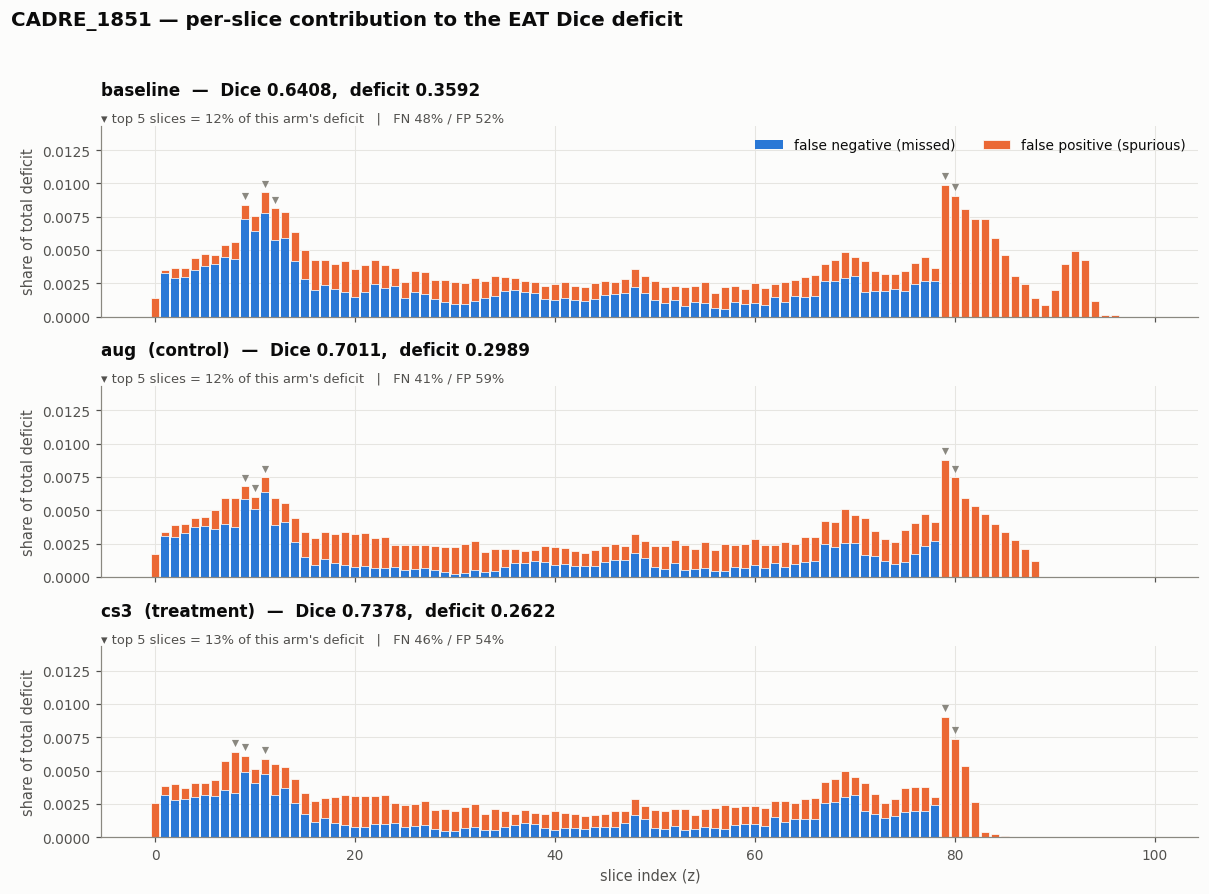

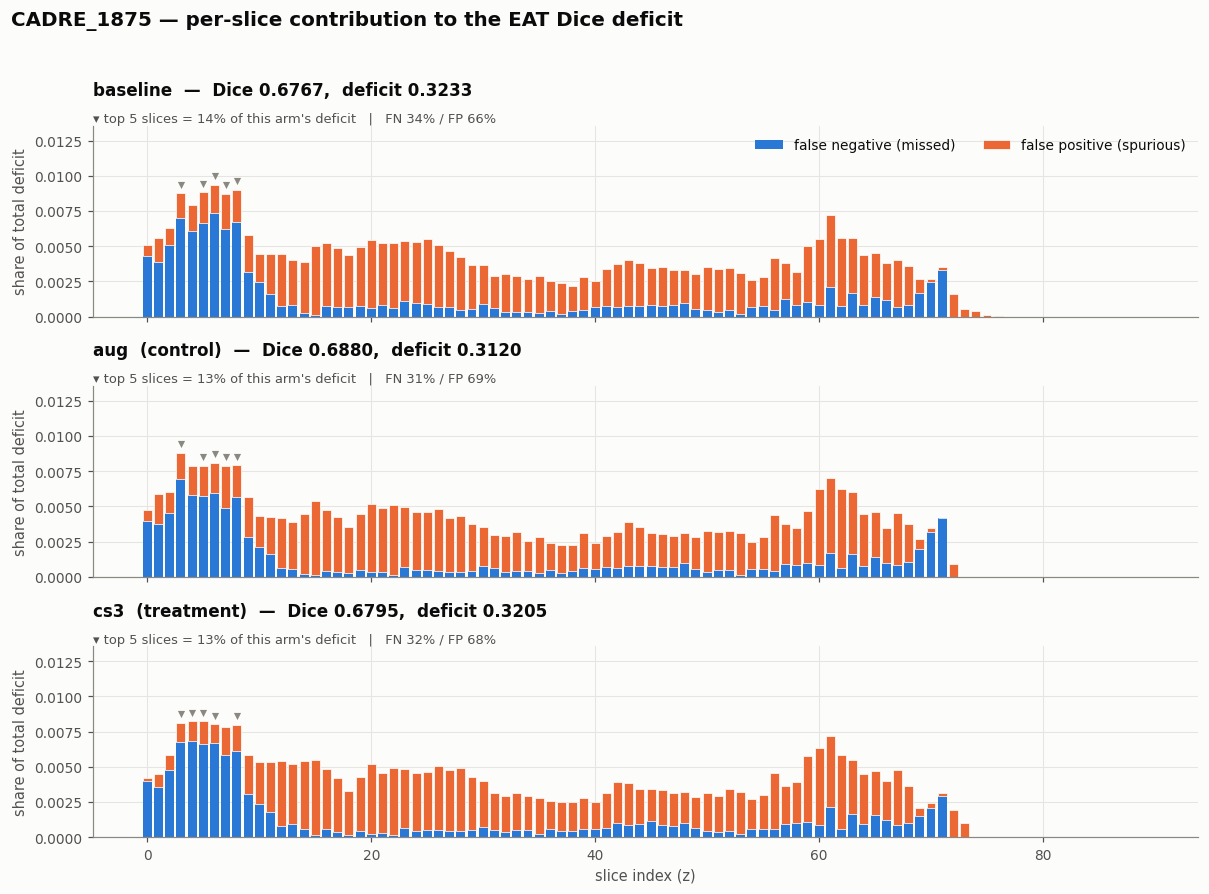

In [11]:
for pid in PATIENTS:
    n_z = len(R[(pid, CONTROL)]['deficit'])
    ymax = max(R[(pid, a)]['deficit'].max() for a in ARMS) * 1.45

    fig, axes = plt.subplots(len(ARMS), 1, figsize=(11, 2.75 * len(ARMS)),
                             sharex=True, sharey=True)
    for ax, arm in zip(np.atleast_1d(axes), ARMS):
        r = R[(pid, arm)]
        z = np.arange(n_z)
        ax.bar(z, r['deficit_fn'], width=0.8, color=FN_COLOR, linewidth=0, label='false negative (missed)')
        ax.bar(z, r['deficit_fp'], width=0.8, bottom=r['deficit_fn'], color=FP_COLOR,
               linewidth=0.5, edgecolor=SURFACE, label='false positive (spurious)')
        top = np.argsort(r['deficit'])[::-1][:5]
        ax.scatter(top, r['deficit'][top] + ymax * 0.045, marker='v', s=22,
                   color=INK_MUTED, linewidth=0, zorder=4)
        share = r['deficit'][top].sum() / r['deficit'].sum()
        tag = {CONTROL: '  (control)', TREATMENT: '  (treatment)'}.get(arm, '')
        ax.set_title(f'{arm}{tag}  —  Dice {r["dice_vol"]:.4f},  deficit {1 - r["dice_vol"]:.4f}')
        subtitle(ax, f'▾ top 5 slices = {share:.0%} of this arm\'s deficit   |   '
                     f'FN {r["deficit_fn"].sum() / r["deficit"].sum():.0%} / '
                     f'FP {r["deficit_fp"].sum() / r["deficit"].sum():.0%}')
        ax.set_ylim(0, ymax)
        ax.set_ylabel('share of total deficit')
    np.atleast_1d(axes)[0].legend(loc='upper right', ncol=2)
    np.atleast_1d(axes)[-1].set_xlabel('slice index (z)')
    fig.suptitle(f'{pid} — per-slice contribution to the EAT Dice deficit',
                 x=0.005, ha='left', fontsize=13, fontweight='semibold')
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

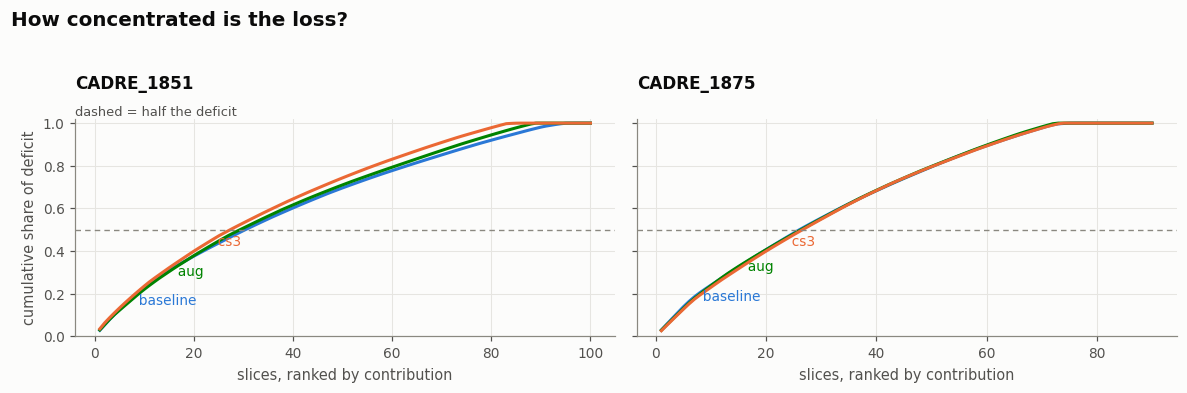

patient       arm          slices for 50% of deficit   for 80%
CADRE_1851    baseline                            31        64
CADRE_1851    aug                                 30        61
CADRE_1851    cs3                                 28        57
CADRE_1875    baseline                            27        51
CADRE_1875    aug                                 27        51
CADRE_1875    cs3                                 27        51


In [12]:
# concentration: how few slices account for how much of the deficit
fig, axes = plt.subplots(1, len(PATIENTS), figsize=(5.4 * len(PATIENTS), 3.6), sharey=True)
axes = np.atleast_1d(axes)

for ax, pid in zip(axes, PATIENTS):
    for i, arm in enumerate(ARMS):
        r = R[(pid, arm)]
        srt = np.sort(r['deficit'])[::-1]
        cum = np.cumsum(srt) / srt.sum()
        k = np.arange(1, len(cum) + 1)
        ax.plot(k, cum, color=ARM_COLOR[arm], linewidth=2.0)
        j = min(6 + 8 * i, len(cum) - 1)          # stagger labels so arms do not collide
        ax.text(k[j], cum[j], f'  {arm}', color=ARM_COLOR[arm], fontsize=9, va='center')
    ax.axhline(0.5, color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 3)))
    ax.set_title(pid)
    ax.set_xlabel('slices, ranked by contribution')
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel('cumulative share of deficit')
subtitle(axes[0], 'dashed = half the deficit')
fig.suptitle('How concentrated is the loss?', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print(f'{"patient":<14}{"arm":<10}{"slices for 50% of deficit":>28}{"for 80%":>10}')
for pid in PATIENTS:
    for arm in ARMS:
        cum = np.cumsum(np.sort(R[(pid, arm)]['deficit'])[::-1]); cum /= cum[-1]
        print(f'{pid:<14}{arm:<10}{int(np.searchsorted(cum, 0.5)) + 1:>28}{int(np.searchsorted(cum, 0.8)) + 1:>10}')

## 4. *Why* — what the errors actually are

Two questions the location alone cannot answer:

- **What is EAT being confused with?** For every false-positive EAT voxel, what does the
  ground truth say it is; for every false negative, what did the model call it instead.
- **Rim or region?** Error voxels touching a correctly-predicted EAT voxel are boundary
  jitter on a thin, diffuse structure — largely irreducible, given EAT's perimeter-to-volume
  ratio. Errors away from any correct EAT are missed regions and hallucinations: the
  genuinely fixable part.

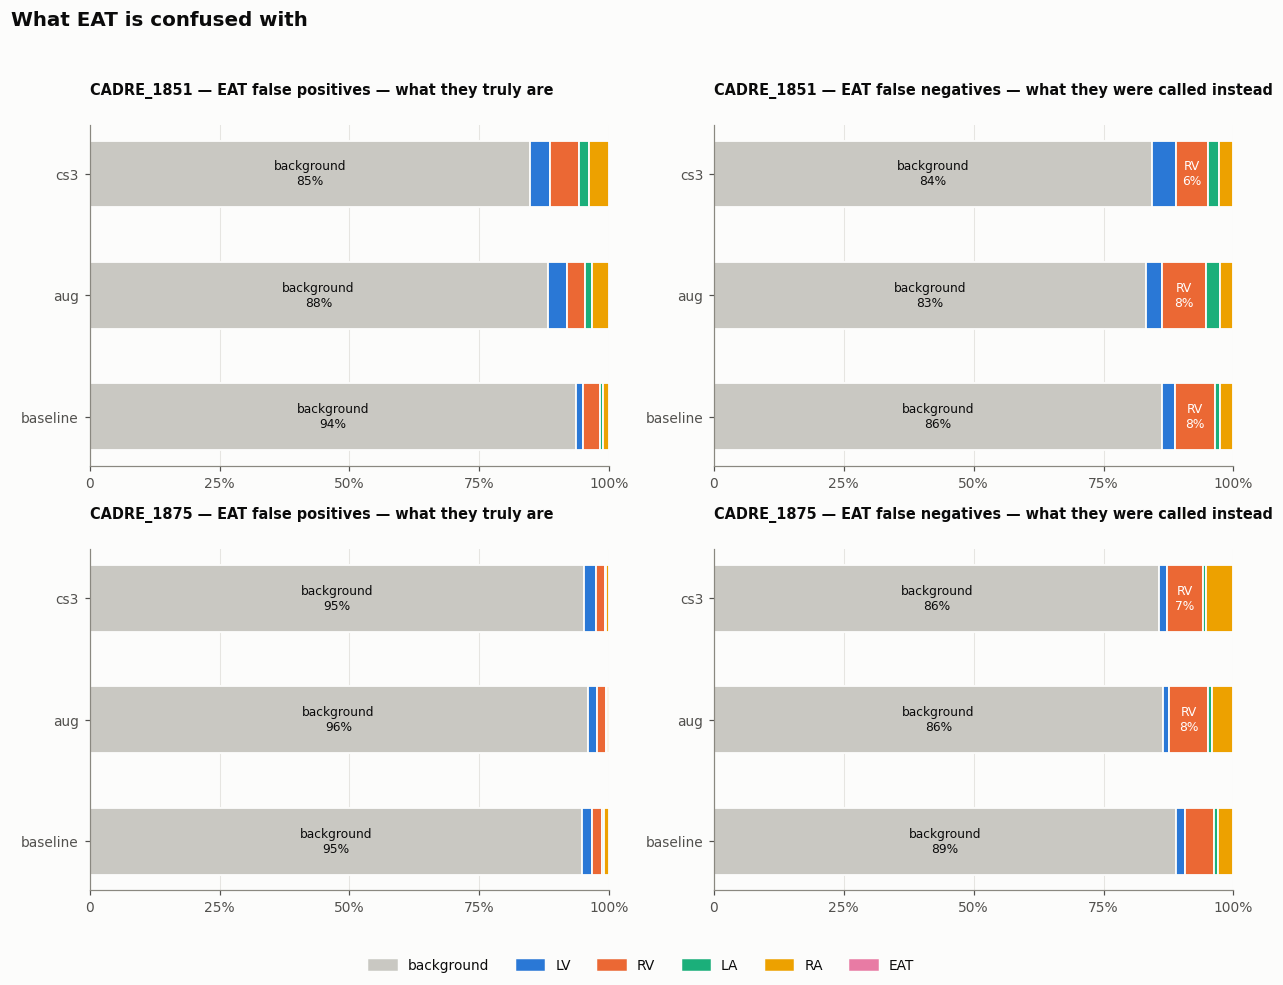

patient     arm       error  background          LV          RV          LA          RA         EAT
1851        baseline  FP         93.6%       1.4%       3.3%       0.7%       1.1%       0.0%
1851        baseline  FN         86.2%       2.5%       7.8%       0.9%       2.6%       0.0%
1851        aug       FP         88.1%       3.8%       3.4%       1.3%       3.3%       0.0%
1851        aug       FN         83.1%       3.1%       8.5%       2.8%       2.5%       0.0%
1851        cs3       FP         84.7%       3.9%       5.6%       1.8%       3.9%       0.0%
1851        cs3       FN         84.3%       4.5%       6.2%       2.2%       2.7%       0.0%
1875        baseline  FP         94.7%       1.9%       2.0%       0.4%       1.0%       0.0%
1875        baseline  FN         89.0%       1.6%       5.7%       0.7%       3.0%       0.0%
1875        aug       FP         95.8%       1.9%       1.7%       0.2%       0.4%       0.0%
1875        aug       FN         86.4%       1.2%     

In [13]:
LABEL_COLOR = {0: '#c9c8c2', 1: C_BLUE, 2: C_ORANGE, 3: C_AQUA, 4: C_YELLOW, 5: C_MAGENTA}

fig, axes = plt.subplots(len(PATIENTS), 2, figsize=(11.5, 1.5 * len(ARMS) * len(PATIENTS)))
axes = np.atleast_2d(axes)

for row, pid in zip(axes, PATIENTS):
    for ax, (key, title) in zip(row, [('fp_true_label', 'EAT false positives — what they truly are'),
                                      ('fn_pred_label', 'EAT false negatives — what they were called instead')]):
        arms = list(ARMS)
        for y, arm in enumerate(arms):
            v = R[(pid, arm)]['attribution'][key]
            v = v / max(v.sum(), 1)
            left = 0.0
            for cls in range(len(v)):
                if v[cls] <= 0:
                    continue
                ax.barh(y, v[cls], left=left, height=0.55, color=LABEL_COLOR[cls],
                        edgecolor=SURFACE, linewidth=1.2)
                if v[cls] > 0.06:
                    ax.text(left + v[cls] / 2, y, f'{CLASS_LBL[cls]}\n{v[cls]:.0%}', ha='center',
                            va='center', fontsize=8, color=INK if cls in (0, 4) else 'white')
                left += v[cls]
        ax.set_yticks(range(len(arms)), arms)
        ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1], ['0', '25%', '50%', '75%', '100%'])
        ax.grid(axis='y', visible=False)
        ax.set_title(f'{pid} — {title}', fontsize=9.5)

fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=LABEL_COLOR[c], label=CLASS_LBL[c])
                    for c in range(len(CLASS_LBL))],
           loc='lower center', ncol=len(CLASS_LBL), frameon=False, fontsize=9)
fig.suptitle('What EAT is confused with', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0.05, 1, 0.96))
plt.show()

# table view -- the stacks are dominated by one category and three fills sit under 3:1 on the surface
print(f'{"patient":<12}{"arm":<10}{"error":<5}' + ''.join(f'{CLASS_LBL[c]:>12}' for c in range(len(CLASS_LBL))))
for pid in PATIENTS:
    for arm in ARMS:
        for key, tag in [('fp_true_label', 'FP'), ('fn_pred_label', 'FN')]:
            v = R[(pid, arm)]['attribution'][key]; v = v / max(v.sum(), 1)
            print(f'{pid.replace("CADRE_", ""):<12}{arm:<10}{tag:<5}' + ''.join(f'{x:>11.1%}' for x in v))

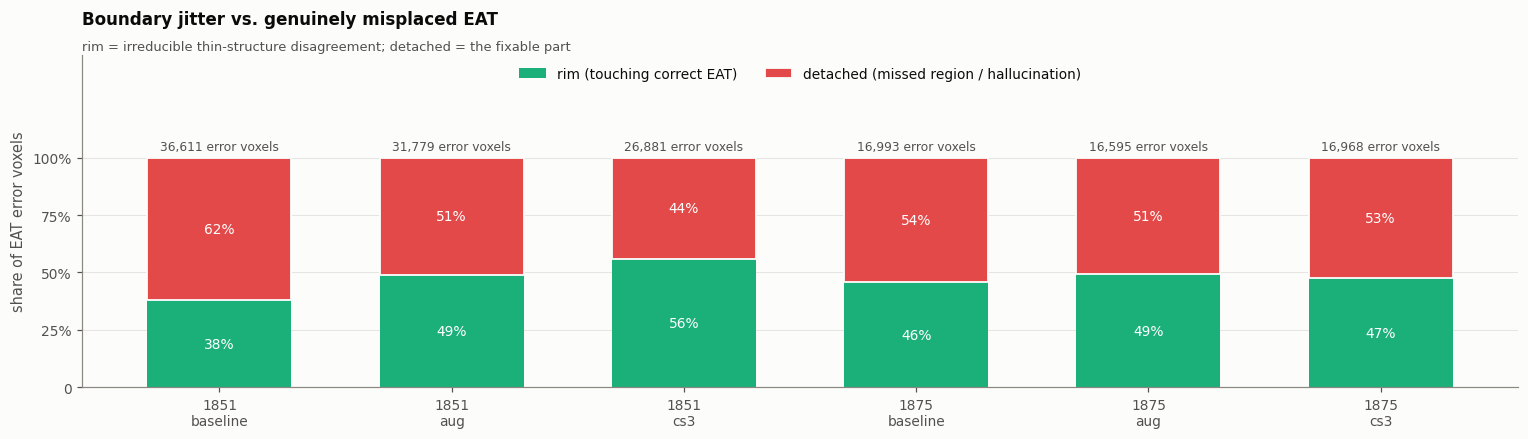

In [14]:
fig, ax = plt.subplots(figsize=(2.0 * len(PATIENTS) * len(ARMS) + 2.0, 4.1))
labels, rim_share, det_share, ticks = [], [], [], []
for pid in PATIENTS:
    for arm in ARMS:
        r = R[(pid, arm)]['rim']
        labels.append(f'{pid.replace("CADRE_", "")}\n{arm}')
        rim_share.append(r['rim'] / r['total'])
        det_share.append(r['detached'] / r['total'])
        ticks.append(r['total'])

x = np.arange(len(labels))
ax.bar(x, rim_share, width=0.62, color=C_AQUA, linewidth=0, label='rim (touching correct EAT)')
ax.bar(x, det_share, width=0.62, bottom=rim_share, color=C_RED, edgecolor=SURFACE,
       linewidth=1.2, label='detached (missed region / hallucination)')
for xi, (rm, d, tot) in enumerate(zip(rim_share, det_share, ticks)):
    ax.text(xi, rm / 2, f'{rm:.0%}', ha='center', va='center', fontsize=9, color='white')
    ax.text(xi, rm + d / 2, f'{d:.0%}', ha='center', va='center', fontsize=9, color='white')
    ax.text(xi, 1.02, f'{tot:,} error voxels', ha='center', va='bottom', fontsize=8, color=INK_2)
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.45); ax.set_yticks([0, .25, .5, .75, 1], ['0', '25%', '50%', '75%', '100%'])
ax.set_ylabel('share of EAT error voxels')
ax.grid(axis='x', visible=False)
ax.legend(loc='upper center', ncol=2)
ax.set_title('Boundary jitter vs. genuinely misplaced EAT')
subtitle(ax, 'rim = irreducible thin-structure disagreement; detached = the fixable part')
fig.tight_layout()
plt.show()

## 5. The worst slices, rendered

For each arm, the three slices contributing most to that arm's deficit: water image with
ground-truth (blue) and predicted (orange) EAT contours, and the model's per-pixel
prediction entropy. Confident errors and uncertain errors call for different fixes.

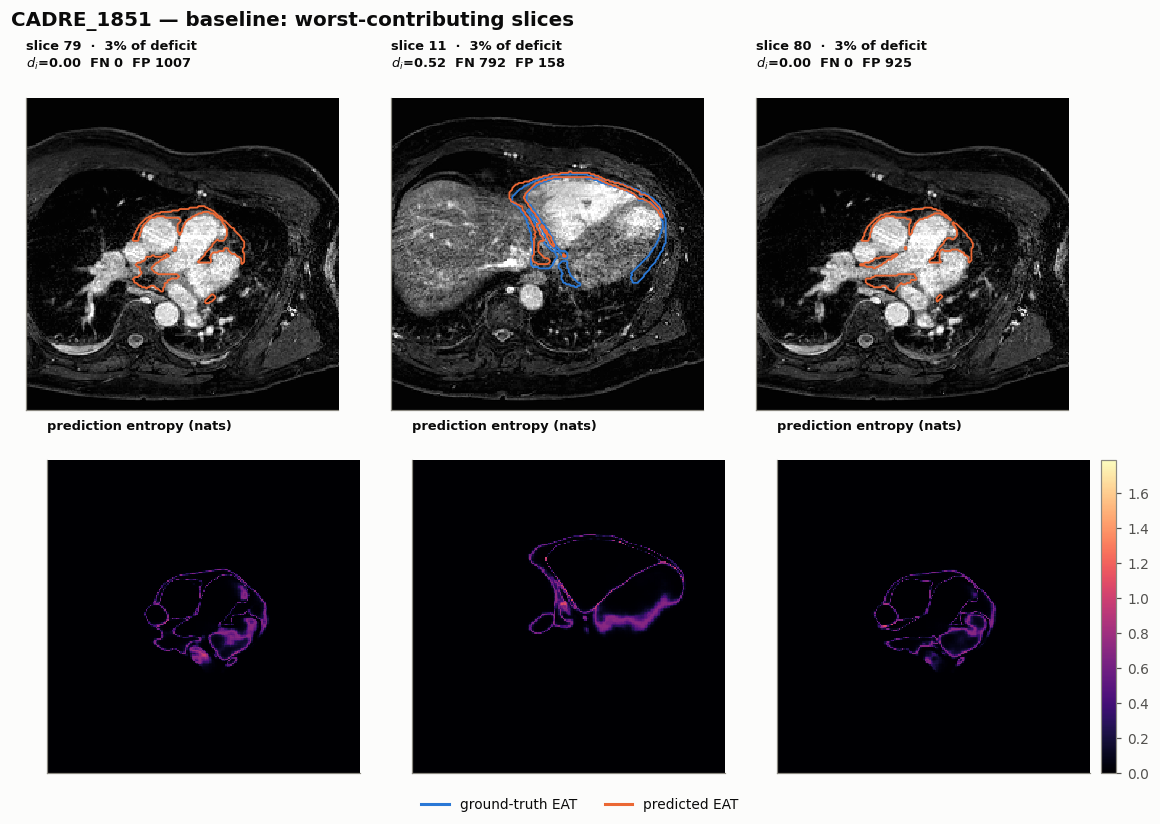

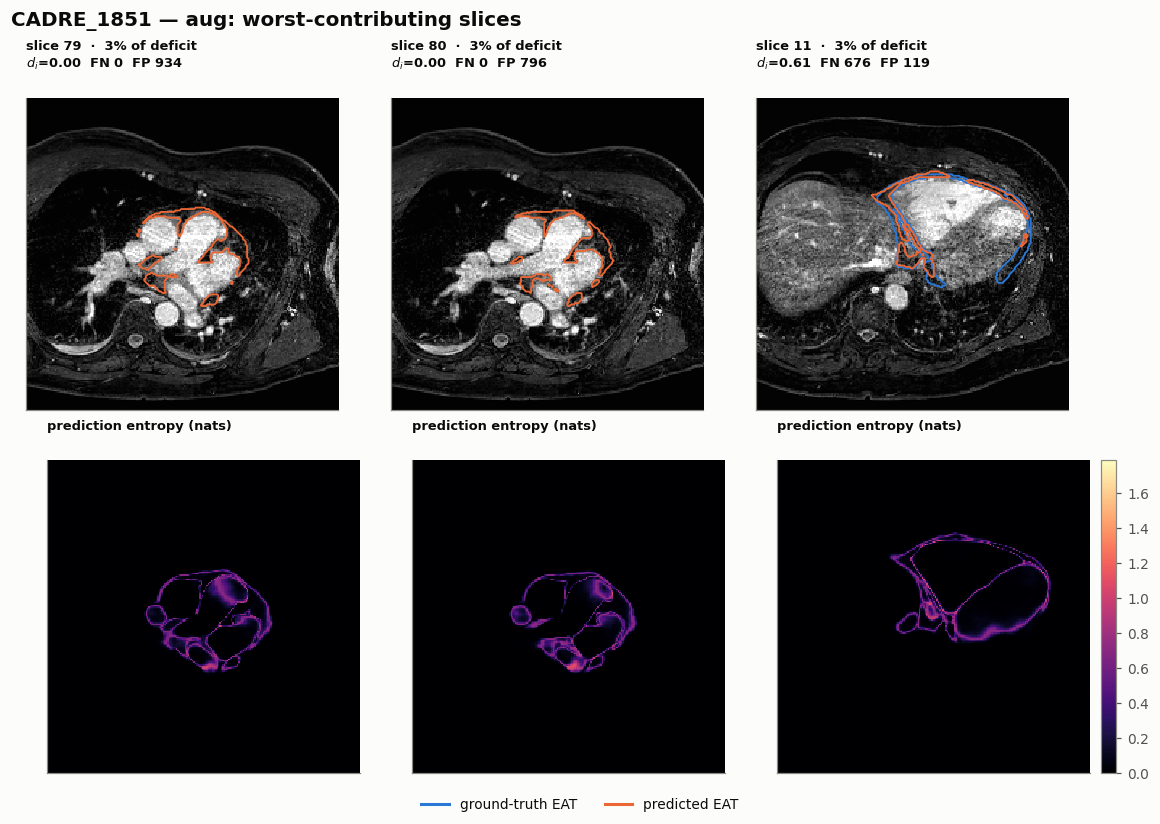

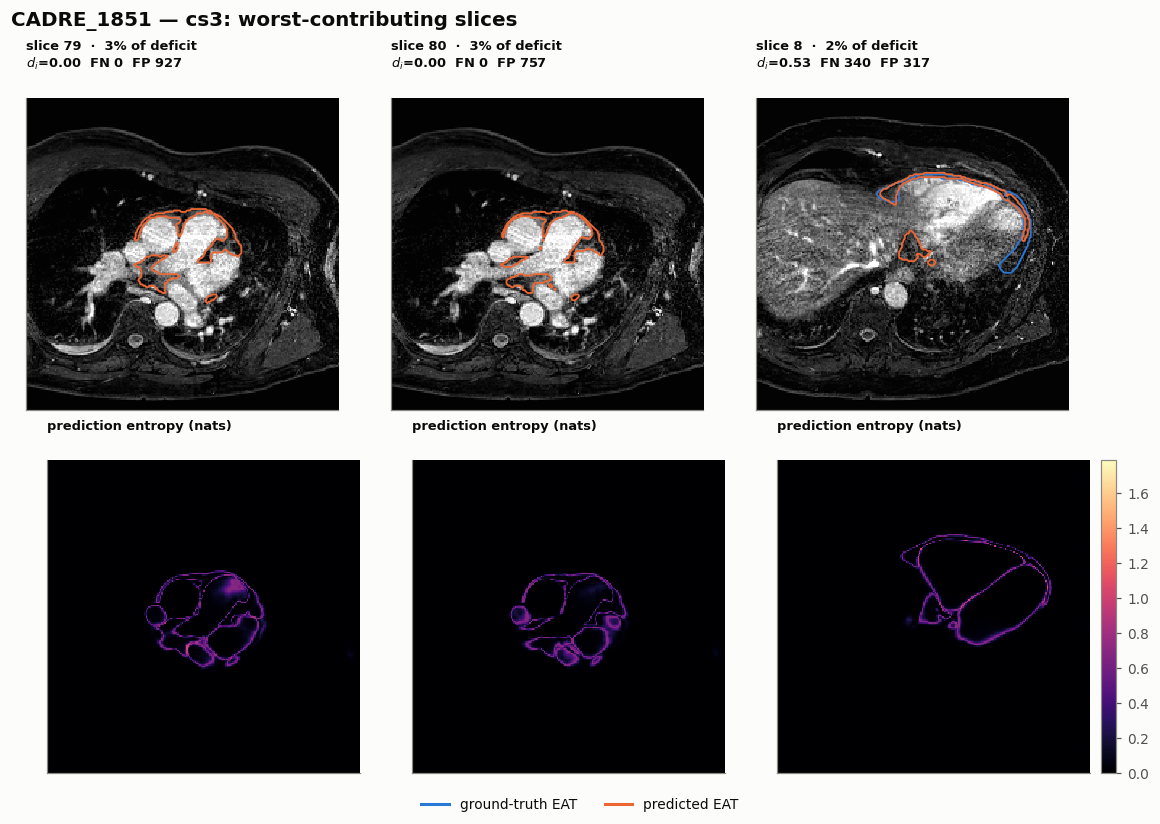

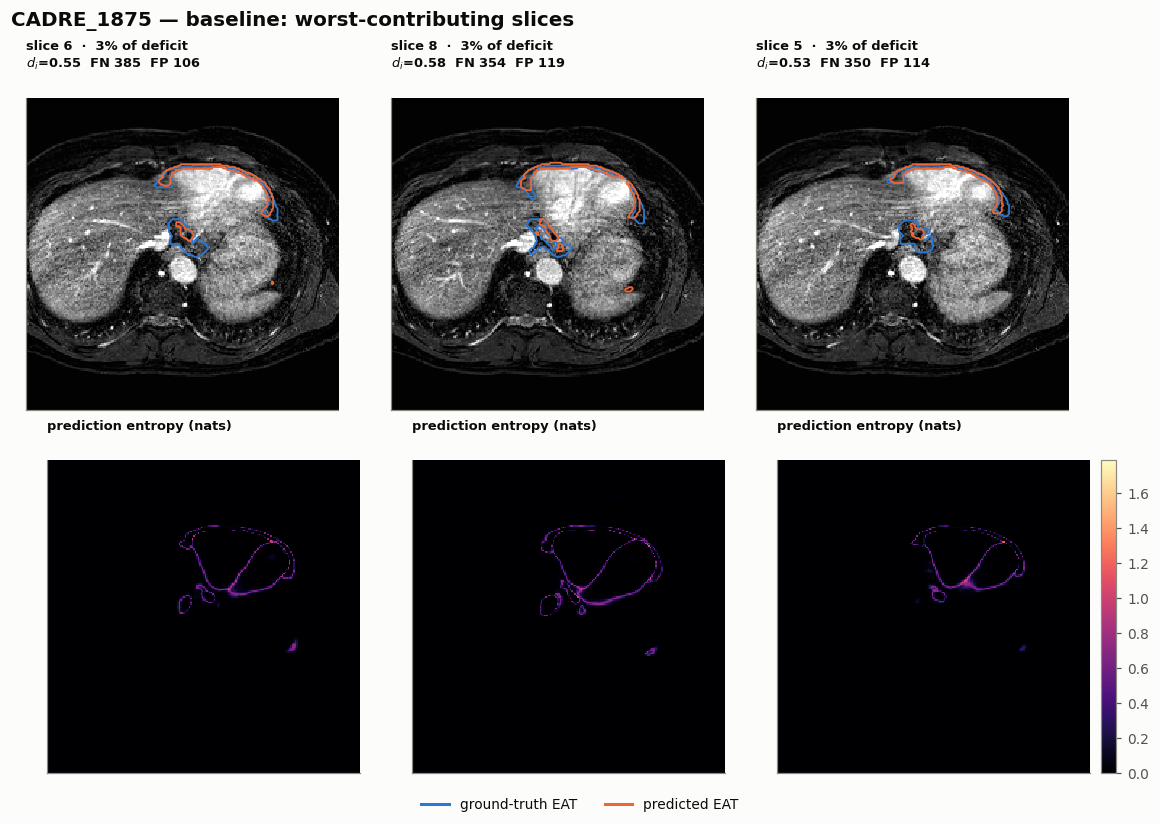

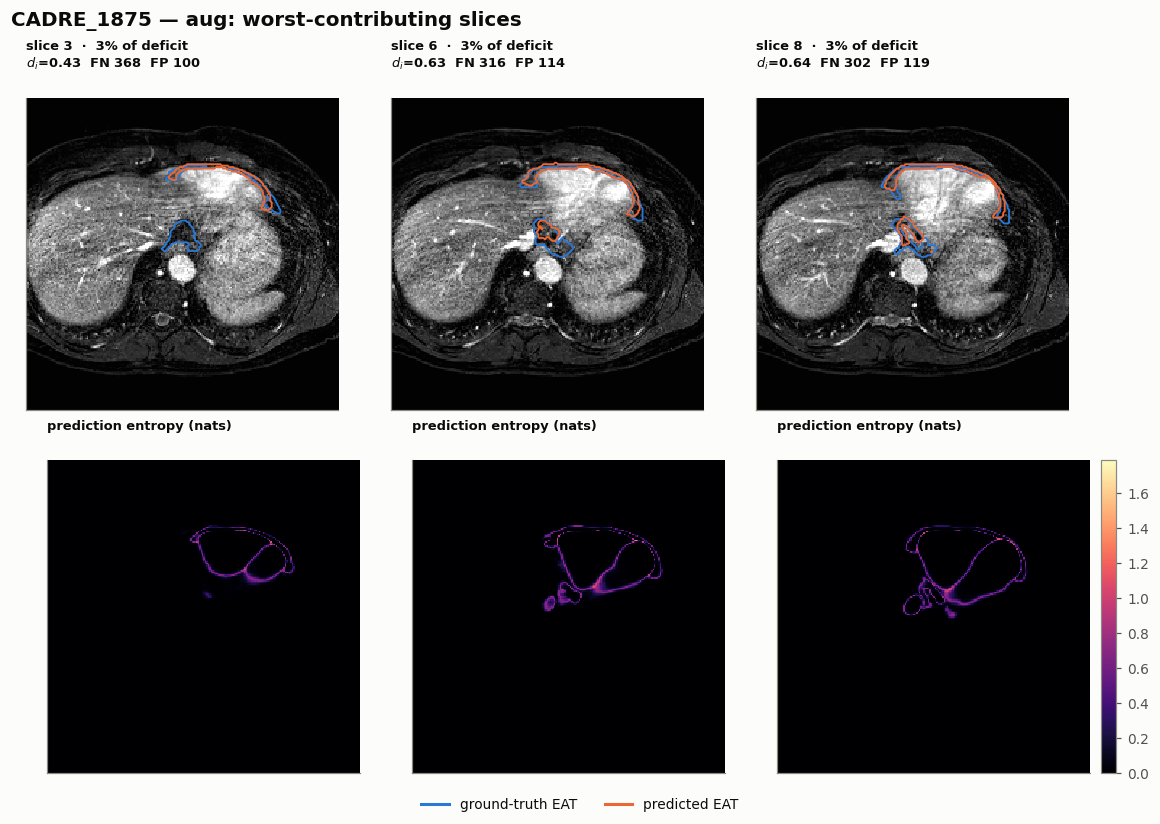

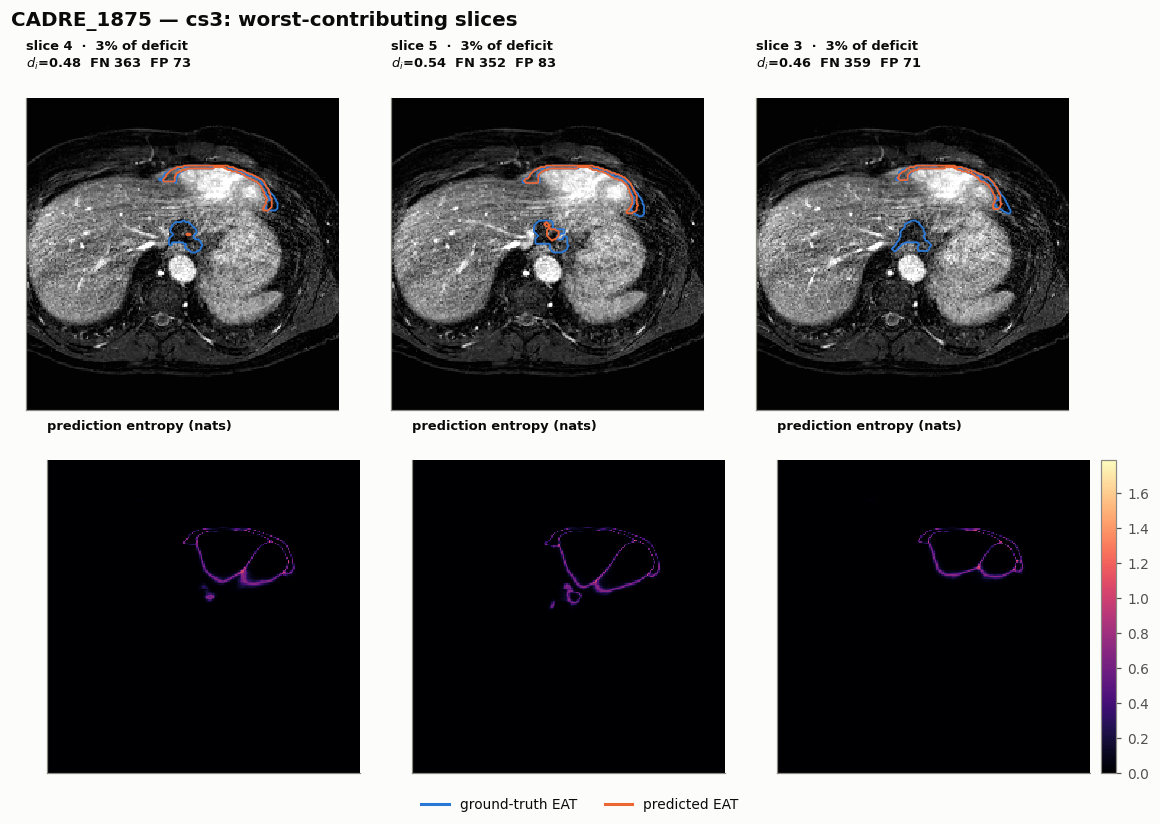

In [15]:
def center_water(rec, k):
    # water channel of the centre slice (channels are water-window then fat-window)
    img = rec['dataset'][rec['indices'][k]]['image'].numpy()
    window = 2 * rec['cfg']['context_slices'] + 1
    return img[window // 2]

for pid in PATIENTS:
    for arm in ARMS:
        r = R[(pid, arm)]
        worst = np.argsort(r['deficit'])[::-1][:3]
        fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.4), layout='constrained')
        for col, k in enumerate(worst):
            img = center_water(r, int(k))
            gt, pr = r['gt_vol'][k] == EAT_CLS, r['pred_vol'][k] == EAT_CLS

            ax = axes[0, col]
            ax.imshow(img, cmap='gray', interpolation='nearest')
            if gt.any(): ax.contour(gt, levels=[0.5], colors=[C_BLUE], linewidths=1.2)
            if pr.any(): ax.contour(pr, levels=[0.5], colors=[C_ORANGE], linewidths=1.2)
            ax.set_title(f'slice {k}  ·  {r["deficit"][k] / r["deficit"].sum():.0%} of deficit\n'
                         f'$d_i$={r["dice_slice"][k]:.2f}  FN {int(r["fn"][k])}  FP {int(r["fp"][k])}',
                         fontsize=8.5)

            ax = axes[1, col]
            im = ax.imshow(r['entropy'][k], cmap='magma', interpolation='nearest',
                           vmin=0, vmax=np.log(r['cfg']['n_classes']))
            ax.set_title('prediction entropy (nats)', fontsize=8.5)
        for ax in axes.ravel():
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        fig.colorbar(im, ax=axes[1, :], fraction=0.03, pad=0.01)
        fig.legend(handles=[Line2D([], [], color=C_BLUE, lw=2, label='ground-truth EAT'),
                            Line2D([], [], color=C_ORANGE, lw=2, label='predicted EAT')],
                   loc='outside lower center', ncol=2, frameon=False)
        fig.suptitle(f'{pid} — {arm}: worst-contributing slices',
                     x=0.01, ha='left', fontsize=13, fontweight='semibold')
        plt.show()

## 6. Summary table

Everything above, as numbers.

In [16]:
print(f'{"patient":<12}{"arm":<10}{"dice":>8}{"deficit":>9}{"FN%":>6}{"FP%":>6}'
      f'{"n50":>5}{"n80":>5}{"detached%":>11}{"top-5 share":>13}')
for pid in PATIENTS:
    for arm in ARMS:
        r = R[(pid, arm)]
        dfc = r['deficit']; cum = np.cumsum(np.sort(dfc)[::-1]) / dfc.sum()
        print(f'{pid.replace("CADRE_", ""):<12}{arm:<10}{r["dice_vol"]:>8.4f}{dfc.sum():>9.4f}'
              f'{100 * r["deficit_fn"].sum() / dfc.sum():>6.0f}{100 * r["deficit_fp"].sum() / dfc.sum():>6.0f}'
              f'{int(np.searchsorted(cum, .5)) + 1:>5}{int(np.searchsorted(cum, .8)) + 1:>5}'
              f'{100 * r["rim"]["detached"] / r["rim"]["total"]:>11.0f}'
              f'{np.sort(dfc)[::-1][:5].sum() / dfc.sum():>13.0%}')
print('\nn50 / n80 = number of slices accounting for 50% / 80% of that arm\'s Dice deficit.')

patient     arm           dice  deficit   FN%   FP%  n50  n80  detached%  top-5 share
1851        baseline    0.6408   0.3592    48    52   31   64         62          12%
1851        aug         0.7011   0.2989    41    59   30   61         51          12%
1851        cs3         0.7378   0.2622    46    54   28   57         44          13%
1875        baseline    0.6767   0.3233    34    66   27   51         54          14%
1875        aug         0.6880   0.3120    31    69   27   51         51          13%
1875        cs3         0.6795   0.3205    32    68   27   51         53          13%

n50 / n80 = number of slices accounting for 50% / 80% of that arm's Dice deficit.


---

# Part II — the same analysis, averaged over every validation patient

Two patients show *what* a failure looks like; they cannot say what is typical. Everything
above is repeated here over the **whole pooled validation cohort** — every patient that is
a validation case in exactly one fold of all three arms — using the identical decomposition,
so the two views are directly comparable.

Three rules make the averaging honest:

- **The patient is the unit of analysis.** Every quantity is reduced to one number per
  patient first, then averaged across patients (mean ± SD, `ddof=1`). Pooling slices would
  let long volumes and large hearts vote more than once.
- **Depth is normalised, not slice index.** Volumes here run 75–108 slices, so slice 40 is
  not the same anatomy in two patients. Each volume is cut into `NBINS` equal-depth bins and
  every per-slice quantity is *summed* within a bin — summing, not interpolating, is what
  keeps the exact identity intact: after binning, $\sum_b W_b D_b$ is still the volume Dice
  and the stacked bars still sum to $1-\mathrm{Dice}$. The next-but-one cell asserts both.
- **Nothing is selected on the outcome.** The cohort is every eligible patient; no
  patient is dropped for being easy, hard, or inconvenient.

The two case patients are carried through as highlights so it is visible where they sit in
the distribution they were drawn from.

In [17]:
# --- the cohort: every patient that is a validation case in all three arms ---
# Same folds in every arm, so each patient is scored by a model that never trained on it,
# and the three arms are paired on that patient. ~3.5 min on a V100 (42 patients x 3 arms).
VAL_FOLD = {}
for arm, cfgs in CFGS.items():
    for f, c in cfgs.items():
        for pid in c['val_patients']:
            VAL_FOLD.setdefault(pid, {})[arm] = f

COHORT = sorted(pid for pid, d in VAL_FOLD.items()
                if len(d) == len(ARMS) and len(set(d.values())) == 1)
assert set(PATIENTS) <= set(COHORT), 'the case patients must belong to the cohort they came from'

# the config check from above, now over EVERY cohort patient rather than the two cases
TEST_PATIENTS = set(CFGS[CONTROL][VAL_FOLD[COHORT[0]][CONTROL]]['test_patients'])
for pid in COHORT:
    fold = VAL_FOLD[pid][CONTROL]
    ref = CFGS[CONTROL][fold]
    assert pid not in TEST_PATIENTS, f'{pid} is a TEST patient — do not score it here'
    for arm, spec in ARMS.items():
        c = CFGS[arm][fold]
        for k in FACTORS:
            assert c[k] == spec[k], f'{arm} fold {fold}: declared {k}={spec[k]}, run has {c[k]}'
        for k in SHARED:
            assert c.get(k) == ref.get(k), \
                f'fold {fold}: {arm} differs from {CONTROL} on {k} ({c.get(k)} vs {ref.get(k)})'
print(f'cohort: {len(COHORT)} patients over folds {sorted({VAL_FOLD[p][CONTROL] for p in COHORT})}, '
      f'{len(ARMS)} arms, no test patient among them')

# Only the compact per-slice arrays are kept. Holding 126 label volumes plus entropy maps
# would run to several GB; §13 re-runs the handful of volumes it actually needs to draw.
COH = {}
for j, pid in enumerate(COHORT, 1):
    fold, gt_ref = VAL_FOLD[pid][CONTROL], None
    for arm in ARMS:
        cfg = CFGS[arm][fold]
        ds, net = get_dataset(cfg), get_model(cfg)
        pred_vol, gt_vol = metrics.predict_volume(net, ds, patient_indices(ds, pid), device,
                                                  amp=False, batch_size=8)
        if gt_ref is None:
            gt_ref = gt_vol
        else:
            assert np.array_equal(gt_ref, gt_vol), f'{pid}: arms disagree on ground truth'
        rec = decompose(pred_vol, gt_vol)
        rec.update(attribution=error_attribution(pred_vol, gt_vol),
                   rim=rim_vs_detached(pred_vol, gt_vol), fold=fold,
                   # which slices the annotator actually drew on -- see §11
                   annotated=metrics.annotated_slices(gt_vol), n_slices=int(pred_vol.shape[0]))
        COH[(pid, arm)] = rec
    print(f'[{j:>2}/{len(COHORT)}] {pid:<18} fold {fold}  n={COH[(pid, CONTROL)]["n_slices"]:>3}  '
          + '  '.join(f'{a} {COH[(pid, a)]["dice_vol"]:.4f}' for a in ARMS), flush=True)

cohort: 42 patients over folds [0, 1, 2, 3, 4], 3 arms, no test patient among them


[ 1/42] CADRE_1116_second  fold 4  n=106  baseline 0.7915  aug 0.7775  cs3 0.7823


/tmp/ipykernel_20548/3767430556.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(cfg['_dir'] / 'best.pth', map_location='cpu')


[ 2/42] CADRE_1131         fold 1  n= 87  baseline 0.7385  aug 0.7343  cs3 0.7312


[ 3/42] CADRE_1382_first   fold 1  n= 94  baseline 0.7566  aug 0.7599  cs3 0.7693


...

[38/42] CADRE_1870         fold 2  n= 94  baseline 0.7891  aug 0.7925  cs3 0.7890


[39/42] CADRE_1871         fold 1  n=100  baseline 0.7311  aug 0.7504  cs3 0.7286


[40/42] CADRE_1872         fold 0  n= 94  baseline 0.8061  aug 0.8154  cs3 0.8173


[41/42] CADRE_1874         fold 4  n= 94  baseline 0.7273  aug 0.7225  cs3 0.7113


[42/42] CADRE_1875         fold 0  n= 90  baseline 0.6767  aug 0.6880  cs3 0.6795


In [18]:
# --- verify every one of them against the numbers already on disk -----------
bad = []
for pid in COHORT:
    for arm in ARMS:
        got = COH[(pid, arm)]['dice_vol']
        exp = recorded(arm, VAL_FOLD[pid][arm], pid)
        if abs(got - exp) >= 2e-3:
            bad.append((pid, arm, got, exp))
assert not bad, bad
print(f'all {len(COHORT) * len(ARMS)} (patient, arm) volume Dice values reproduce '
      f'val_metrics_per_patient.csv to <2e-3 — the cohort decomposition is trustworthy.')

# and the cohort really is the same 42 patients the pooled CSV comparison in §0 used
assert set(COHORT) == set(pids), 'cohort disagrees with the pooled per-patient CSVs of §0'
print(f'cohort matches the §0 pooled validation set exactly (n={len(COHORT)}).')

all 126 (patient, arm) volume Dice values reproduce val_metrics_per_patient.csv to <2e-3 — the cohort decomposition is trustworthy.
cohort matches the §0 pooled validation set exactly (n=42).


In [19]:
# --- aggregation: per-slice arrays -> equal-depth bins -> one row per patient ---
# Summing within a depth bin (rather than interpolating onto a grid) is what keeps the
# decomposition exact after averaging: bin weights still sum to 1, bin deficits still sum
# to 1 - Dice. Both are asserted below, for every patient and arm.
NBINS = 20                                   # ~4-5 slices per bin at 75-108 slices
BIN_MID = (np.arange(NBINS) + 0.5) / NBINS

def depth_bin(n):
    return np.minimum(((np.arange(n) + 0.5) / n * NBINS).astype(int), NBINS - 1)

def binsum(vals, n):
    return np.bincount(depth_bin(n), weights=np.nan_to_num(vals), minlength=NBINS)

def stack(arm, fn):
    """One row per cohort patient, in COHORT order — so rows stay paired across arms."""
    return np.array([fn(COH[(pid, arm)]) for pid in COHORT])

N = len(COHORT)
GT_PROF  = {a: stack(a, lambda r: binsum(r['gt'],   len(r['gt'])) / r['gt'].sum()) for a in ARMS}
PR_PROF  = {a: stack(a, lambda r: binsum(r['pred'], len(r['gt'])) / r['gt'].sum()) for a in ARMS}
W_BIN    = {a: stack(a, lambda r: binsum(r['w'], len(r['w'])))                     for a in ARMS}
WD_BIN   = {a: stack(a, lambda r: binsum(r['w'] * np.nan_to_num(r['dice_slice']), len(r['w'])))
            for a in ARMS}
DEF_FN   = {a: stack(a, lambda r: binsum(r['deficit_fn'], len(r['deficit'])))      for a in ARMS}
DEF_FP   = {a: stack(a, lambda r: binsum(r['deficit_fp'], len(r['deficit'])))      for a in ARMS}
DICE     = {a: stack(a, lambda r: r['dice_vol'])                                   for a in ARMS}
with np.errstate(invalid='ignore', divide='ignore'):
    DICE_BIN = {a: np.where(W_BIN[a] > 0, WD_BIN[a] / W_BIN[a], np.nan) for a in ARMS}

for a in ARMS:
    assert np.allclose(np.nansum(WD_BIN[a], 1), DICE[a]),            f'{a}: binned Dice identity broken'
    assert np.allclose(DEF_FN[a].sum(1) + DEF_FP[a].sum(1), 1 - DICE[a]), f'{a}: binned deficit identity broken'
print(f'binned identity holds for all {N} patients x {len(ARMS)} arms — '
      f'the averaged bars below still sum to 1 - Dice.')

binned identity holds for all 42 patients x 3 arms — the averaged bars below still sum to 1 - Dice.


## 7. Extent profile, cohort mean

The §1 plot, with each patient normalised by its own total EAT voxels so a large heart does
not outvote a small one, and depth expressed as a fraction of the volume. The lower panel is
the same information as a signed error — where the cohort systematically adds EAT and where
it drops it.

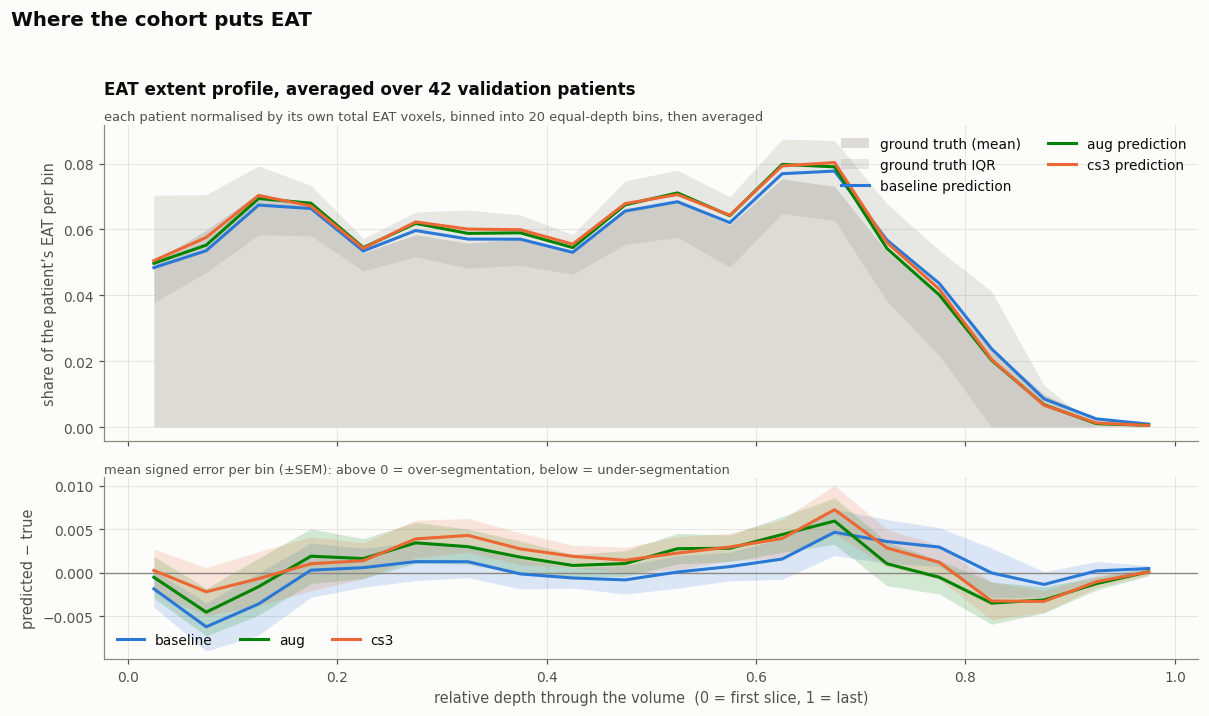

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True,
                         gridspec_kw=dict(height_ratios=[2, 1.15]))

ax = axes[0]
gt_m = GT_PROF[CONTROL].mean(0)
q1, q3 = np.percentile(GT_PROF[CONTROL], [25, 75], axis=0)
ax.fill_between(BIN_MID, gt_m, color='#dcdbd6', linewidth=0, label='ground truth (mean)', zorder=1)
ax.fill_between(BIN_MID, q1, q3, color=INK_MUTED, alpha=0.18, linewidth=0,
                label='ground truth IQR', zorder=2)
for arm in ARMS:
    ax.plot(BIN_MID, PR_PROF[arm].mean(0), color=ARM_COLOR[arm], label=f'{arm} prediction', zorder=3)
ax.set_ylabel('share of the patient’s EAT per bin')
ax.set_title(f'EAT extent profile, averaged over {N} validation patients')
subtitle(ax, f'each patient normalised by its own total EAT voxels, binned into {NBINS} '
             'equal-depth bins, then averaged')
ax.legend(loc='upper right', ncol=2)

ax = axes[1]
ax.axhline(0, color=INK_MUTED, linewidth=0.9)
for arm in ARMS:
    diff = PR_PROF[arm] - GT_PROF[arm]
    m, sem = diff.mean(0), diff.std(0, ddof=1) / np.sqrt(N)
    ax.plot(BIN_MID, m, color=ARM_COLOR[arm], label=arm)
    ax.fill_between(BIN_MID, m - sem, m + sem, color=ARM_COLOR[arm], alpha=0.16, linewidth=0)
ax.set_xlabel('relative depth through the volume  (0 = first slice, 1 = last)')
ax.set_ylabel('predicted − true')
subtitle(ax, 'mean signed error per bin (±SEM): above 0 = over-segmentation, below = under-segmentation')
ax.legend(loc='lower left', ncol=len(ARMS))

fig.suptitle('Where the cohort puts EAT', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()

## 8. Per-slice Dice against slice weight, cohort mean

The §2 plot, aggregated. Within a depth bin the slices are combined the way the identity
requires — $D_b=\sum_{i\in b} w_i d_i \big/ \sum_{i\in b} w_i$ — and it is those bin values
that are averaged across patients, so $\sum_b W_b D_b$ is still exactly the volume Dice.
Marker area is the mean bin weight: where the score is actually decided.

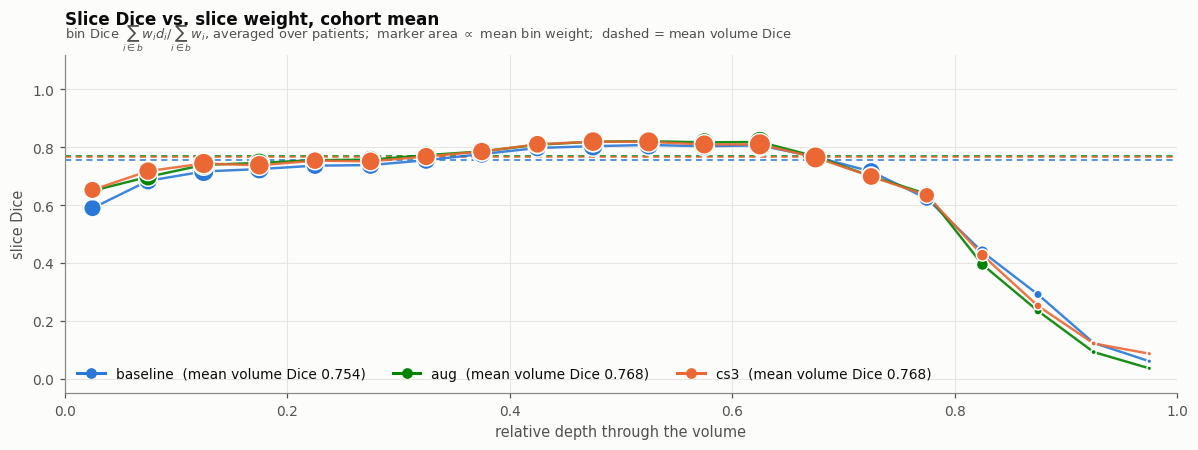

In [21]:
fig, ax = plt.subplots(figsize=(11, 4.2))

for arm in ARMS:
    m = np.nanmean(DICE_BIN[arm], 0)
    w = W_BIN[arm].mean(0)
    ax.plot(BIN_MID, m, color=ARM_COLOR[arm], linewidth=1.6, alpha=0.9, zorder=2)
    ax.scatter(BIN_MID, m, s=8 + 2500 * w, color=ARM_COLOR[arm], edgecolor=SURFACE,
               linewidth=1.0, zorder=3)
    ax.axhline(DICE[arm].mean(), color=ARM_COLOR[arm], linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)

ax.set_ylim(-0.05, 1.12)
ax.set_xlim(0, 1)
ax.set_xlabel('relative depth through the volume')
ax.set_ylabel('slice Dice')
ax.set_title('Slice Dice vs. slice weight, cohort mean')
subtitle(ax, 'bin Dice $\\sum_{i\\in b} w_i d_i / \\sum_{i\\in b} w_i$, averaged over patients;  '
             'marker area $\\propto$ mean bin weight;  dashed = mean volume Dice')
ax.legend(handles=[Line2D([], [], color=ARM_COLOR[a], lw=2, marker='o', markersize=6,
                          label=f'{a}  (mean volume Dice {DICE[a].mean():.3f})') for a in ARMS],
          loc='lower left', ncol=len(ARMS))
fig.tight_layout()
plt.show()

## 9. The headline, cohort mean — where the deficit lives, and is it FP or FN?

The §3 bars, averaged. Heights are the mean over patients of the binned $w_i(1-d_i)$, split
into its false-negative and false-positive halves, so **the bars still sum exactly to the
mean deficit** $1-\overline{\mathrm{Dice}}$ and the three panels are comparable in absolute
terms.

One caution when reading this against §3: averaging over patients at fixed *depth* deliberately
does **not** show concentration. A patient's worst slices are its own — they land at different
depths in different patients — so the mean profile is flatter than any individual profile.
The next cell measures concentration the only way that survives averaging: rank the slices
**within** each patient first, then average the resulting curves.

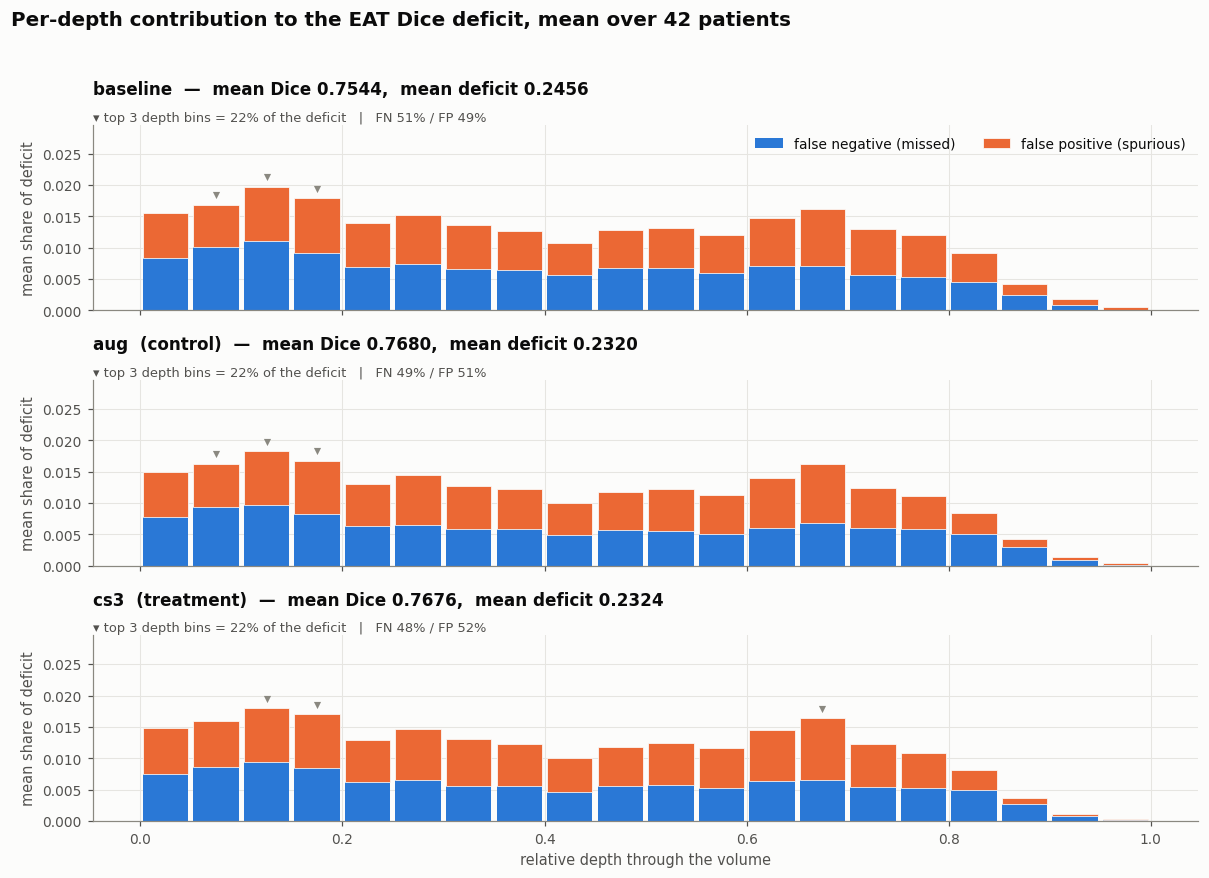

In [22]:
ymax = max((DEF_FN[a].mean(0) + DEF_FP[a].mean(0)).max() for a in ARMS) * 1.5

fig, axes = plt.subplots(len(ARMS), 1, figsize=(11, 2.7 * len(ARMS)), sharex=True, sharey=True)
for ax, arm in zip(np.atleast_1d(axes), ARMS):
    fn, fp = DEF_FN[arm].mean(0), DEF_FP[arm].mean(0)
    tot = fn + fp
    ax.bar(BIN_MID, fn, width=0.045, color=FN_COLOR, linewidth=0, label='false negative (missed)')
    ax.bar(BIN_MID, fp, width=0.045, bottom=fn, color=FP_COLOR, linewidth=0.5,
           edgecolor=SURFACE, label='false positive (spurious)')
    top = np.argsort(tot)[::-1][:3]
    ax.scatter(BIN_MID[top], tot[top] + ymax * 0.05, marker='v', s=22, color=INK_MUTED,
               linewidth=0, zorder=4)
    tag = {CONTROL: '  (control)', TREATMENT: '  (treatment)'}.get(arm, '')
    ax.set_title(f'{arm}{tag}  —  mean Dice {DICE[arm].mean():.4f},  mean deficit {tot.sum():.4f}')
    subtitle(ax, f'▾ top 3 depth bins = {tot[top].sum() / tot.sum():.0%} of the deficit   |   '
                 f'FN {fn.sum() / tot.sum():.0%} / FP {fp.sum() / tot.sum():.0%}')
    ax.set_ylim(0, ymax)
    ax.set_ylabel('mean share of deficit')
np.atleast_1d(axes)[0].legend(loc='upper right', ncol=2)
np.atleast_1d(axes)[-1].set_xlabel('relative depth through the volume')

fig.suptitle(f'Per-depth contribution to the EAT Dice deficit, mean over {N} patients',
             x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

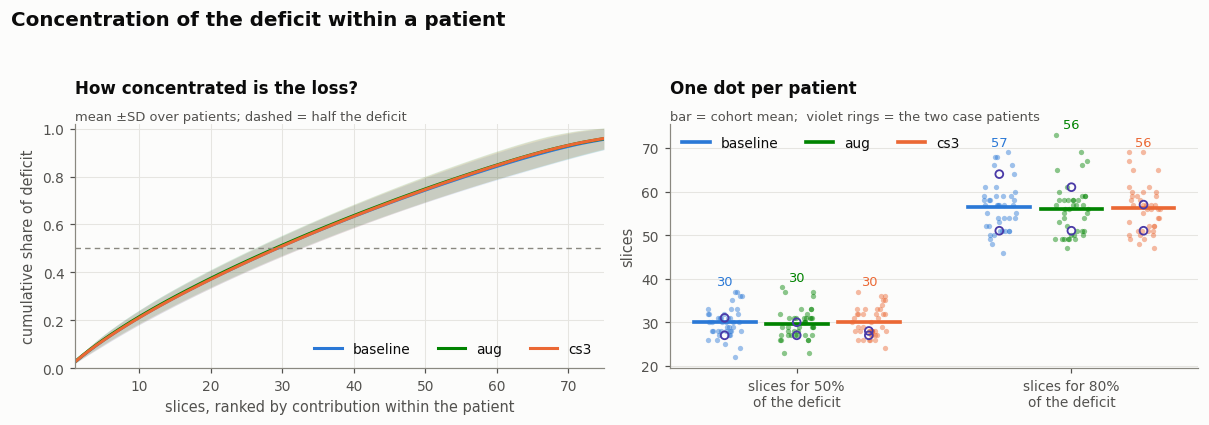

In [23]:
# concentration, measured within each patient and then averaged -- the cohort version of §3b
KMAX = min(len(COH[(p, CONTROL)]['deficit']) for p in COHORT)   # shortest volume in the cohort

def conc_curve(rec, kmax=KMAX):
    s = np.sort(rec['deficit'])[::-1]
    return (np.cumsum(s) / s.sum())[:kmax]

def n_for(rec, frac):
    c = np.cumsum(np.sort(rec['deficit'])[::-1])
    return int(np.searchsorted(c / c[-1], frac)) + 1

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
k = np.arange(1, KMAX + 1)
ax = axes[0]
for arm in ARMS:
    cur = np.array([conc_curve(COH[(p, arm)]) for p in COHORT])
    m, s = cur.mean(0), cur.std(0, ddof=1)
    ax.plot(k, m, color=ARM_COLOR[arm], label=arm)
    ax.fill_between(k, m - s, m + s, color=ARM_COLOR[arm], alpha=0.13, linewidth=0)
ax.axhline(0.5, color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 3)))
ax.set_xlabel('slices, ranked by contribution within the patient')
ax.set_ylabel('cumulative share of deficit')
ax.set_xlim(1, KMAX); ax.set_ylim(0, 1.02)
ax.set_title('How concentrated is the loss?')
subtitle(ax, 'mean ±SD over patients; dashed = half the deficit')
ax.legend(loc='lower right', ncol=len(ARMS))

ax = axes[1]
rng = np.random.default_rng(0)
for i, arm in enumerate(ARMS):
    for j, frac in enumerate((0.5, 0.8)):
        v = np.array([n_for(COH[(p, arm)], frac) for p in COHORT])
        x = j * 1.6 + i * 0.42
        ax.scatter(np.full(N, x) + rng.uniform(-.1, .1, N), v, s=12, color=ARM_COLOR[arm],
                   alpha=0.45, linewidth=0)
        ax.plot([x - .18, x + .18], [v.mean()] * 2, color=ARM_COLOR[arm], linewidth=2.4)
        ax.text(x, v.max() + 1.5, f'{v.mean():.0f}', ha='center', fontsize=8.5, color=ARM_COLOR[arm])
        for pid in PATIENTS:                      # where the two cases sit
            ax.scatter([x], [n_for(COH[(pid, arm)], frac)], s=26, facecolor='none',
                       edgecolor=C_VIOLET, linewidth=1.2, zorder=4)
ax.set_xticks([0.42, 2.02], ['slices for 50%\nof the deficit', 'slices for 80%\nof the deficit'])
ax.set_ylabel('slices')
ax.grid(axis='x', visible=False)
ax.set_title('One dot per patient')
subtitle(ax, 'bar = cohort mean;  violet rings = the two case patients')
ax.legend(handles=[Line2D([], [], color=ARM_COLOR[a], lw=2.4, label=a) for a in ARMS],
          loc='upper left', ncol=len(ARMS))

fig.suptitle('Concentration of the deficit within a patient', x=0.005, ha='left',
             fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## 10. Does the deficit sit where the annotator stopped drawing?

The masks in this dataset are truncated — `metrics.annotated_slices` exists because labelling
stops at a z where the anatomy plainly continues, and on those slices an anatomically correct
prediction is scored as a false positive. Two versions of that worry are separable, and the
cell below measures both per patient:

- **outside the annotated block** — no class is drawn on the slice at all;
- **inside it, but with no EAT drawn** — chambers labelled, EAT left blank.

Both turn out to be real but small: ~16% of slices carry no annotation, yet under 3% of the
EAT deficit lands there, and the second category is a few tenths of a percent. Every error in
either category is a false positive by construction — there is no ground truth to miss — and
the cell asserts that rather than assuming it.

Worth holding on to for §13: the single worst slice in the cohort under the control arm is of
the *second* kind (369 predicted EAT voxels, none drawn). So the phenomenon is conspicuous
case-by-case while contributing almost nothing in aggregate — which is the entire reason for
this second part.

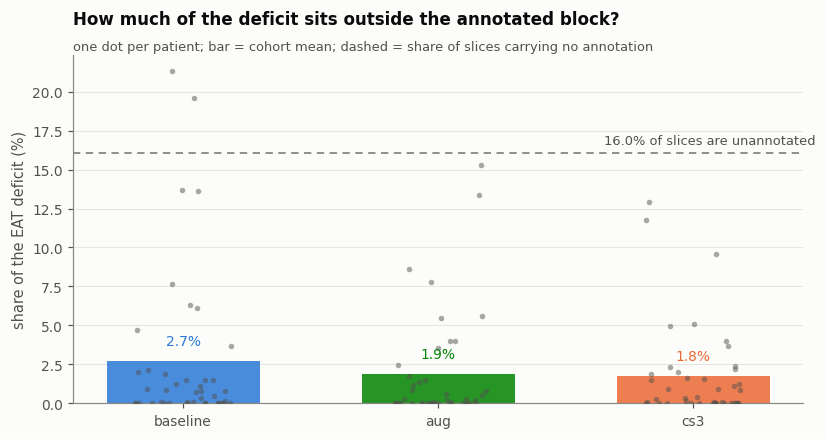

baseline    2.7% ± 5.2 of the deficit outside the annotated block   |   30/42 patients spill at all   |   worst patient 21.3%
            0.3% ± 0.9 on slices that ARE annotated but carry no EAT   |   worst patient 3.9%
aug         1.9% ± 3.6 of the deficit outside the annotated block   |   24/42 patients spill at all   |   worst patient 15.3%
            0.3% ± 0.8 on slices that ARE annotated but carry no EAT   |   worst patient 3.7%
cs3         1.8% ± 3.1 of the deficit outside the annotated block   |   27/42 patients spill at all   |   worst patient 12.9%
            0.3% ± 1.0 on slices that ARE annotated but carry no EAT   |   worst patient 4.3%


In [24]:
# share of each patient's deficit falling on slices the annotator never drew on
NO_EAT  = {a: np.array([100 * COH[(p, a)]['deficit'][COH[(p, a)]['annotated'] & (COH[(p, a)]['gt'] == 0)].sum()
                        / COH[(p, a)]['deficit'].sum() for p in COHORT]) for a in ARMS}
OUTSIDE = {a: np.array([100 * COH[(p, a)]['deficit'][~COH[(p, a)]['annotated']].sum()
                        / COH[(p, a)]['deficit'].sum() for p in COHORT]) for a in ARMS}
UNANN   = np.array([100 * (~COH[(p, CONTROL)]['annotated']).mean() for p in COHORT])

# no ground truth on those slices, so every error there must be a false positive -- check it
for a in ARMS:
    fn_out = sum(COH[(p, a)]['deficit_fn'][COH[(p, a)]['gt'] == 0].sum() for p in COHORT)
    assert fn_out == 0, f'{a}: false negatives on a slice with no EAT ground truth — impossible'

fig, ax = plt.subplots(figsize=(7.6, 4.1))
rng = np.random.default_rng(0)
for i, arm in enumerate(ARMS):
    ax.bar(i, OUTSIDE[arm].mean(), width=0.6, color=ARM_COLOR[arm], linewidth=0, alpha=0.85)
    ax.scatter(np.full(N, i) + rng.uniform(-.19, .19, N), OUTSIDE[arm], s=13, color=INK_2,
               alpha=0.5, linewidth=0, zorder=3)
    ax.text(i, OUTSIDE[arm].mean() + 1.0, f'{OUTSIDE[arm].mean():.1f}%', ha='center',
            fontsize=9, color=ARM_COLOR[arm])
ax.axhline(UNANN.mean(), color=INK_MUTED, linewidth=1.2, linestyle=(0, (4, 3)))
ax.text(len(ARMS) - 0.52, UNANN.mean() + 0.6, f'{UNANN.mean():.1f}% of slices are unannotated',
        ha='right', fontsize=8.5, color=INK_2)
ax.set_xticks(range(len(ARMS)), list(ARMS))
ax.set_ylabel('share of the EAT deficit (%)')
ax.grid(axis='x', visible=False)
ax.set_title('How much of the deficit sits outside the annotated block?')
subtitle(ax, 'one dot per patient; bar = cohort mean; dashed = share of slices carrying no annotation')
fig.tight_layout()
plt.show()

for arm in ARMS:
    n_spill = int((OUTSIDE[arm] > 0).sum())
    print(f'{arm:<9} {OUTSIDE[arm].mean():5.1f}% ± {OUTSIDE[arm].std(ddof=1):.1f} of the deficit '
          f'outside the annotated block   |   {n_spill}/{N} patients spill at all   '
          f'|   worst patient {OUTSIDE[arm].max():.1f}%')
    print(f'{"":9} {NO_EAT[arm].mean():5.1f}% ± {NO_EAT[arm].std(ddof=1):.1f} on slices that ARE '
          f'annotated but carry no EAT   |   worst patient {NO_EAT[arm].max():.1f}%')

## 11. *Why*, cohort mean — what the errors are made of

§4 repeated over the cohort. Both panels average **per-patient shares**, not pooled voxel
counts: pooling would let the patients with the most error voxels write the answer.

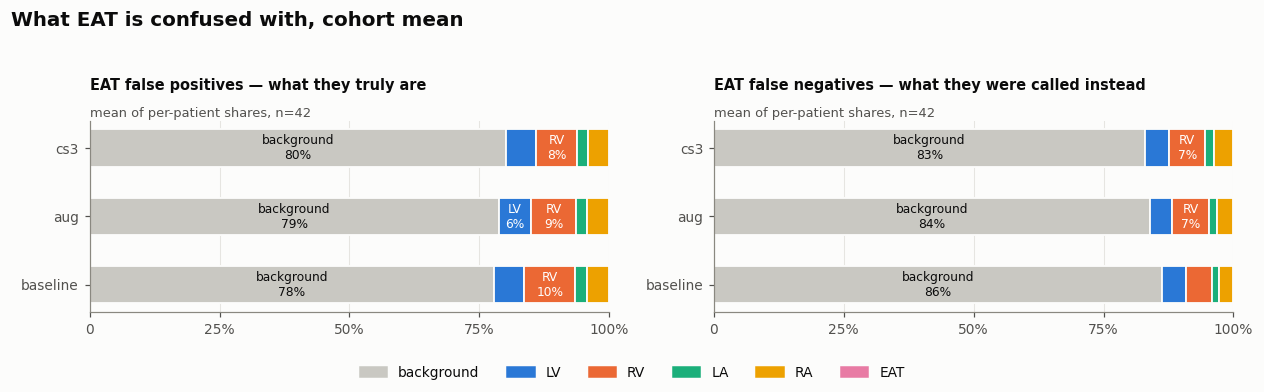

arm       error         background                LV                RV                LA                RA               EAT   mean ± SD over patients
baseline  FP           77.8±12.2          5.8±3.6           9.9±6.9           2.1±1.8           4.4±2.8           0.0±0.0   
baseline  FN           86.3±6.8           4.5±3.0           5.1±3.3           1.3±1.4           2.8±1.7           0.0±0.0   
aug       FP           78.9±11.1          6.1±3.5           8.6±6.5           2.1±1.6           4.3±2.5           0.0±0.0   
aug       FN           83.9±7.9           4.4±3.2           7.0±4.4           1.6±1.6           3.1±2.1           0.0±0.0   
cs3       FP           80.1±9.7           5.8±3.7           7.9±4.9           2.2±1.7           4.0±2.3           0.0±0.0   
cs3       FN           82.9±7.9           4.7±2.9           6.9±4.1           1.7±1.6           3.7±2.1           0.0±0.0   


In [25]:
LABEL_COLOR = {0: '#c9c8c2', 1: C_BLUE, 2: C_ORANGE, 3: C_AQUA, 4: C_YELLOW, 5: C_MAGENTA}
NC = len(CLASS_LBL)

def shares(arm, key):
    out = []
    for pid in COHORT:
        v = COH[(pid, arm)]['attribution'][key]
        v = np.pad(v, (0, max(0, NC - len(v))))[:NC]        # a volume may lack the top label
        out.append(v / max(v.sum(), 1))
    return np.array(out)

SHARE = {(a, k): shares(a, k) for a in ARMS for k in ('fp_true_label', 'fn_pred_label')}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.5))
for ax, (key, title) in zip(axes, [('fp_true_label', 'EAT false positives — what they truly are'),
                                   ('fn_pred_label', 'EAT false negatives — what they were called instead')]):
    for y, arm in enumerate(ARMS):
        v = SHARE[(arm, key)].mean(0)
        left = 0.0
        for cls in range(NC):
            if v[cls] <= 0:
                continue
            ax.barh(y, v[cls], left=left, height=0.55, color=LABEL_COLOR[cls],
                    edgecolor=SURFACE, linewidth=1.2)
            if v[cls] > 0.06:
                ax.text(left + v[cls] / 2, y, f'{CLASS_LBL[cls]}\n{v[cls]:.0%}', ha='center',
                        va='center', fontsize=8, color=INK if cls in (0, 4) else 'white')
            left += v[cls]
    ax.set_yticks(range(len(ARMS)), list(ARMS))
    ax.set_xlim(0, 1)
    ax.set_xticks([0, .25, .5, .75, 1], ['0', '25%', '50%', '75%', '100%'])
    ax.grid(axis='y', visible=False)
    ax.set_title(title, fontsize=9.5)
    subtitle(ax, f'mean of per-patient shares, n={N}')

fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=LABEL_COLOR[c], label=CLASS_LBL[c])
                    for c in range(NC)],
           loc='lower center', ncol=NC, frameon=False, fontsize=9)
fig.suptitle('What EAT is confused with, cohort mean', x=0.005, ha='left', fontsize=13,
             fontweight='semibold')
fig.tight_layout(rect=(0, 0.09, 1, 0.94))
plt.show()

# same thing as numbers, with the spread the bars cannot show
print(f'{"arm":<10}{"error":<6}' + ''.join(f'{CLASS_LBL[c]:>18}' for c in range(NC)) + '   mean ± SD over patients')
for arm in ARMS:
    for key, tag in (('fp_true_label', 'FP'), ('fn_pred_label', 'FN')):
        s = SHARE[(arm, key)]
        print(f'{arm:<10}{tag:<6}' + ''.join(f'{100 * s[:, c].mean():>11.1f}±{100 * s[:, c].std(ddof=1):<6.1f}'
                                             for c in range(NC)))

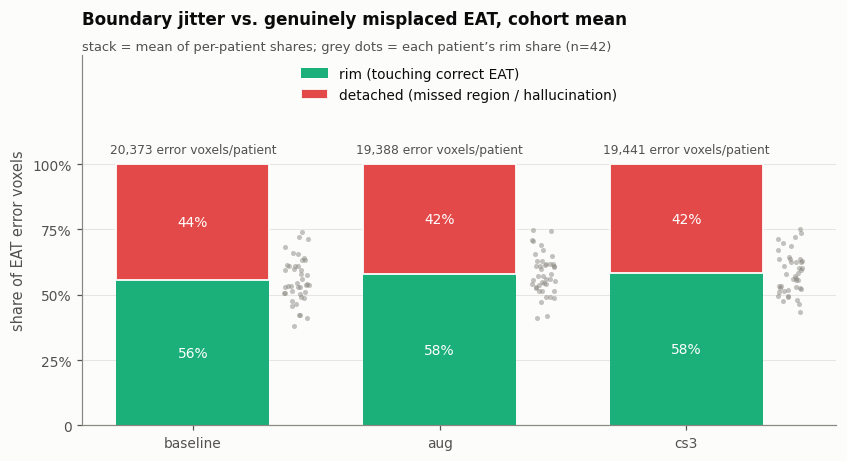

In [26]:
# rim vs detached, cohort mean -- the §4b bar, one stack per arm instead of one per case
DET  = {a: np.array([COH[(p, a)]['rim']['detached'] / COH[(p, a)]['rim']['total'] for p in COHORT])
        for a in ARMS}
ERRV = {a: np.array([COH[(p, a)]['rim']['total'] for p in COHORT]) for a in ARMS}

fig, ax = plt.subplots(figsize=(7.8, 4.3))
rng = np.random.default_rng(0)
for i, arm in enumerate(ARMS):
    rim = 1 - DET[arm].mean()
    ax.bar(i, rim, width=0.62, color=C_AQUA, linewidth=0,
           label='rim (touching correct EAT)' if i == 0 else None)
    ax.bar(i, DET[arm].mean(), width=0.62, bottom=rim, color=C_RED, edgecolor=SURFACE,
           linewidth=1.2, label='detached (missed region / hallucination)' if i == 0 else None)
    ax.text(i, rim / 2, f'{rim:.0%}', ha='center', va='center', fontsize=9, color='white')
    ax.text(i, rim + DET[arm].mean() / 2, f'{DET[arm].mean():.0%}', ha='center', va='center',
            fontsize=9, color='white')
    ax.scatter(np.full(N, i + 0.42) + rng.uniform(-.05, .05, N), 1 - DET[arm], s=11,
               color=INK_MUTED, alpha=0.5, linewidth=0)
    ax.text(i, 1.03, f'{ERRV[arm].mean():,.0f} error voxels/patient', ha='center', va='bottom',
            fontsize=8, color=INK_2)
ax.set_xticks(range(len(ARMS)), list(ARMS))
ax.set_ylim(0, 1.42)
ax.set_yticks([0, .25, .5, .75, 1], ['0', '25%', '50%', '75%', '100%'])
ax.set_ylabel('share of EAT error voxels')
ax.grid(axis='x', visible=False)
ax.legend(loc='upper center')
ax.set_title('Boundary jitter vs. genuinely misplaced EAT, cohort mean')
subtitle(ax, f'stack = mean of per-patient shares; grey dots = each patient’s rim share (n={N})')
fig.tight_layout()
plt.show()

## 12. The distribution the two cases came from

Every patient's EAT Dice under each arm, with the two cases picked out, and the paired
per-patient deltas that §0 summarises in one line each. This is the plot that says whether a
case is representative or extreme.

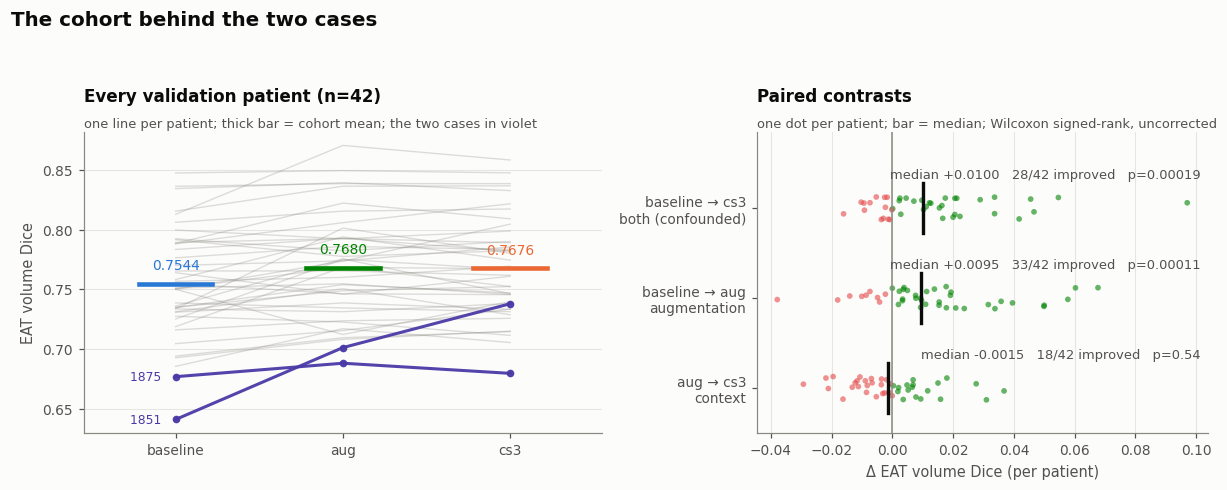

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), gridspec_kw=dict(width_ratios=[1.15, 1]))

ax = axes[0]
xs = np.arange(len(ARMS))
for pid in COHORT:
    y = [COH[(pid, a)]['dice_vol'] for a in ARMS]
    case = pid in PATIENTS
    ax.plot(xs, y, color=C_VIOLET if case else INK_MUTED, alpha=0.95 if case else 0.28,
            linewidth=2.0 if case else 0.9, marker='o' if case else None, markersize=4,
            zorder=3 if case else 1)
    if case:
        ax.text(-0.06, y[0], pid.replace('CADRE_', '') + ' ', ha='right', va='center',
                fontsize=8, color=C_VIOLET)
for i, arm in enumerate(ARMS):
    ax.plot([i - .22, i + .22], [DICE[arm].mean()] * 2, color=ARM_COLOR[arm], linewidth=3, zorder=4)
    ax.text(i, DICE[arm].mean() + .012, f'{DICE[arm].mean():.4f}', ha='center', fontsize=9,
            color=ARM_COLOR[arm], zorder=4)
ax.set_xticks(xs, list(ARMS))
ax.set_xlim(-0.55, len(ARMS) - 0.45)
ax.set_ylabel('EAT volume Dice')
ax.grid(axis='x', visible=False)
ax.set_title(f'Every validation patient (n={N})')
subtitle(ax, 'one line per patient; thick bar = cohort mean; the two cases in violet')

ax = axes[1]
CONTRASTS = [(CONTROL, TREATMENT, 'context'),
             ('baseline', CONTROL, 'augmentation'),
             ('baseline', TREATMENT, 'both (confounded)')]
rng = np.random.default_rng(0)
for i, (a, b, lbl) in enumerate(CONTRASTS):
    dlt = DICE[b] - DICE[a]
    p = wilcoxon(DICE[b], DICE[a]).pvalue
    ax.scatter(dlt, np.full(N, i) + rng.uniform(-.13, .13, N), s=14,
               color=[C_GREEN if v > 0 else C_RED for v in dlt], alpha=0.6, linewidth=0)
    ax.plot([np.median(dlt)] * 2, [i - .28, i + .28], color=INK, linewidth=2.2, zorder=4)
    ax.text(0.985, i + .3, f'median {np.median(dlt):+.4f}   {(dlt > 0).sum()}/{N} improved   '
                           f'p={p:.2g}', transform=ax.get_yaxis_transform(), ha='right',
            va='bottom', fontsize=8.5, color=INK_2)
ax.axvline(0, color=INK_MUTED, linewidth=1.0)
ax.set_yticks(range(len(CONTRASTS)), [f'{a} → {b}\n{lbl}' for a, b, lbl in CONTRASTS])
ax.set_ylim(-0.5, len(CONTRASTS) - 0.15)
ax.set_xlabel('Δ EAT volume Dice (per patient)')
ax.grid(axis='y', visible=False)
ax.set_title('Paired contrasts')
subtitle(ax, 'one dot per patient; bar = median; Wilcoxon signed-rank, uncorrected')

fig.suptitle('The cohort behind the two cases', x=0.005, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## 13. The cohort's worst slices, rendered

The §5 panel has no averaged form — you cannot average a picture — so this is the pooled
version instead: across every patient and every slice, the slices carrying the largest share
of their own patient's deficit, capped at one slice per patient so the panel is not three
views of one bad volume. Shown for the control and the treatment arm.

This is the one figure in Part II selected on an extreme rather than averaged, and it is
labelled as such: read it as "what the tail looks like", with §7–§12 for what is typical.

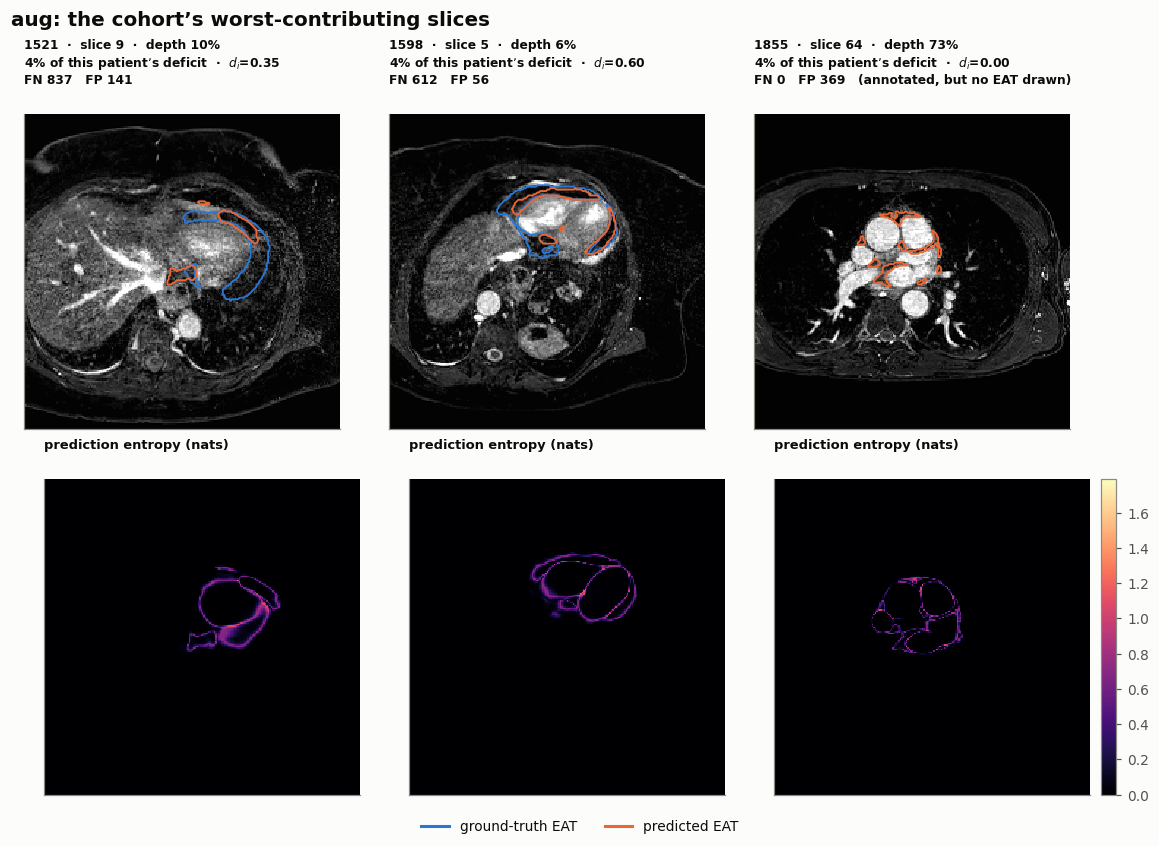

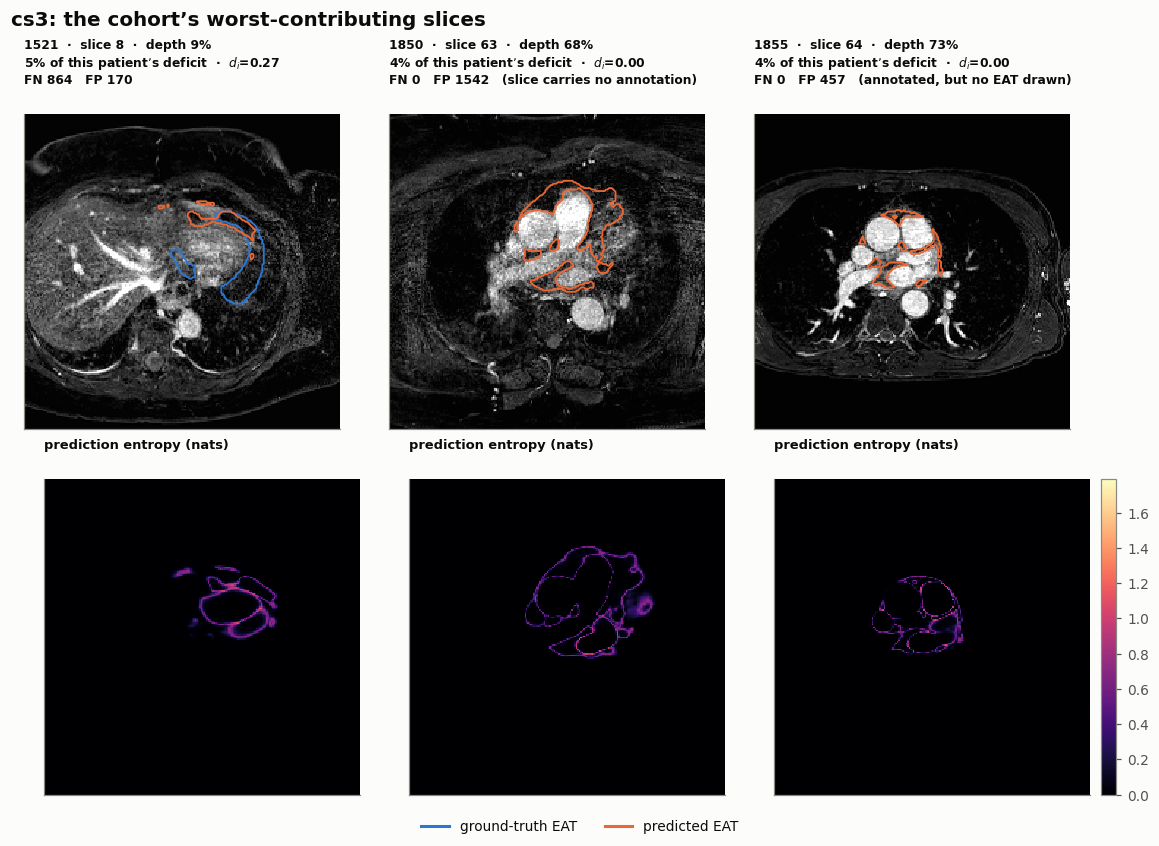

In [28]:
TOPN = 3

for arm in (CONTROL, TREATMENT):
    ranked = sorted(((COH[(pid, arm)]['deficit'][k] / COH[(pid, arm)]['deficit'].sum(), pid, int(k))
                     for pid in COHORT for k in range(len(COH[(pid, arm)]['deficit']))), reverse=True)
    picked, seen = [], set()
    for share, pid, k in ranked:                 # at most one slice per patient
        if pid in seen:
            continue
        seen.add(pid)
        picked.append((share, pid, k))
        if len(picked) == TOPN:
            break

    fig, axes = plt.subplots(2, TOPN, figsize=(3.5 * TOPN, 7.6), layout='constrained')
    for col, (share, pid, k) in enumerate(picked):
        cfg = CFGS[arm][VAL_FOLD[pid][arm]]
        ds, net = get_dataset(cfg), get_model(cfg)
        idxs = sorted(patient_indices(ds, pid), key=lambda i: ds.index[i][1])
        pred_vol, gt_vol, ent = metrics.predict_volume(net, ds, idxs, device, amp=False,
                                                       batch_size=8, return_entropy=True)
        r = COH[(pid, arm)]
        img = ds[idxs[k]]['image'].numpy()[(2 * cfg['context_slices'] + 1) // 2]   # centre, water
        gt, pr = gt_vol[k] == EAT_CLS, pred_vol[k] == EAT_CLS

        ax = axes[0, col]
        ax.imshow(img, cmap='gray', interpolation='nearest')
        if gt.any(): ax.contour(gt, levels=[0.5], colors=[C_BLUE], linewidths=1.2)
        if pr.any(): ax.contour(pr, levels=[0.5], colors=[C_ORANGE], linewidths=1.2)
        ax.set_title(f'{pid.replace("CADRE_", "")}  ·  slice {k}  ·  depth {(k + .5) / len(r["gt"]):.0%}\n'
                     f'{share:.0%} of this patient’s deficit  ·  $d_i$={r["dice_slice"][k]:.2f}\n'
                     f'FN {int(r["fn"][k])}   FP {int(r["fp"][k])}'
                     + ('   (slice carries no annotation)' if not r['annotated'][k]
                        else '   (annotated, but no EAT drawn)' if r['gt'][k] == 0 else ''),
                     fontsize=8)

        ax = axes[1, col]
        im = ax.imshow(ent[k], cmap='magma', interpolation='nearest', vmin=0,
                       vmax=np.log(cfg['n_classes']))
        ax.set_title('prediction entropy (nats)', fontsize=8.5)

    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    fig.colorbar(im, ax=axes[1, :], fraction=0.03, pad=0.01)
    fig.legend(handles=[Line2D([], [], color=C_BLUE, lw=2, label='ground-truth EAT'),
                        Line2D([], [], color=C_ORANGE, lw=2, label='predicted EAT')],
               loc='outside lower center', ncol=2, frameon=False)
    fig.suptitle(f'{arm}: the cohort’s worst-contributing slices', x=0.01, ha='left',
                 fontsize=13, fontweight='semibold')
    plt.show()

## 14. Cohort summary table

Everything above as numbers: mean ± SD across patients (the patient is the unit, so SD is a
between-patient SD, `ddof=1`), then the two case patients on the same scale, then the paired
contrasts.

Redundant columns are omitted rather than double-counted — deficit is $1-\mathrm{Dice}$ and
FP% is $100-$FN%, so neither carries information the table does not already have. The
p-values are **uncorrected and exploratory**: this is a secondary, EAT-only readout of runs
whose pre-specified endpoint is macro Dice, and six statistics × three contrasts is a family
no correction would leave anything alive in. Read the direction and the effect size; treat
significance stars as absent.

In [29]:
STATS = {
    'dice':       lambda r: r['dice_vol'],
    'FN%':        lambda r: 100 * r['deficit_fn'].sum() / r['deficit'].sum(),
    'n50':        lambda r: n_for(r, .5),
    'n80':        lambda r: n_for(r, .8),
    'detached%':  lambda r: 100 * r['rim']['detached'] / r['rim']['total'],
    'top5share%': lambda r: 100 * np.sort(r['deficit'])[::-1][:5].sum() / r['deficit'].sum(),
}
per_patient = lambda arm, fn: np.array([fn(COH[(pid, arm)]) for pid in COHORT])

print(f'cohort, mean ± SD over n={N} patients')
print(f'{"arm":<10}' + ''.join(f'{k:>17}' for k in STATS))
for arm in ARMS:
    print(f'{arm:<10}' + ''.join(
        f'{per_patient(arm, fn).mean():>10.3f}±{per_patient(arm, fn).std(ddof=1):<6.3f}'
        for fn in STATS.values()))

print(f'\nthe two case patients, same columns')
for pid in PATIENTS:
    for arm in ARMS:
        print(f'{pid.replace("CADRE_", ""):<6}{arm:<10}'
              + ''.join(f'{fn(COH[(pid, arm)]):>17.3f}' for fn in STATS.values()))

print(f'\npaired contrasts (Wilcoxon signed-rank, uncorrected, n={N})')
for a, b, lbl in CONTRASTS:
    print(f'\n  {a} → {b}   {lbl}')
    for k, fn in STATS.items():
        x, y = per_patient(a, fn), per_patient(b, fn)
        d = y - x
        p = wilcoxon(y, x).pvalue if np.any(d) else 1.0
        # "up in n/N", not "better in n/N": lower is better for FN%, n50, n80 and detached%
        print(f'    {k:<12} mean {d.mean():+8.3f}   median {np.median(d):+8.3f}   '
              f'up in {(d > 0).sum():>2}/{N}   p={p:.4f}')

print('\nThe cohort tells the same story as §0: the augmentation contrast moves EAT Dice and\n'
      'the context contrast does not. What the decomposition adds is WHERE that gain comes\n'
      'from — augmentation lowers the detached (genuinely misplaced) share of the error while\n'
      'leaving concentration and the confusion profile essentially untouched. It shaves the\n'
      'existing failure mode rather than removing one, which is also why the two cases look\n'
      'qualitatively identical under all three arms.')

cohort, mean ± SD over n=42 patients
arm                    dice              FN%              n50              n80        detached%       top5share%
baseline       0.754±0.045     51.287±13.797    29.952±3.356     56.524±5.636     44.283±8.495     11.704±2.227 
aug            0.768±0.044     50.169±14.152    29.667±3.419     55.929±5.944     41.962±7.834     11.960±1.984 
cs3            0.768±0.042     48.823±13.385    30.000±3.276     56.143±5.577     41.730±7.905     11.692±2.078 

the two case patients, same columns
1851  baseline              0.641           48.119           31.000           64.000           62.014           12.477
1851  aug                   0.701           40.936           30.000           61.000           51.204           12.231
1851  cs3                   0.738           46.300           28.000           57.000           44.210           13.281
1875  baseline              0.677           33.602           27.000           51.000           54.258           13.80